In [5]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
import MixedEffectsModeling.config as config
from viz_style import apply_style
apply_style()


## 1. Load Training Summary & HC Expression Data
풀링(Pooling) 없이 축소(Cascade) 모델링 절차가 적용된 유전자별 결과를 읽어오고 발현량 통계(mean, max, zero fraction, non-zero sample count)를 산출합니다.


In [6]:
import anndata as ad
from scipy.sparse import issparse
from sklearn.preprocessing import StandardScaler

def load_hc(h5ad_path=config.H5AD_PATH):
    adata = ad.read_h5ad(h5ad_path)
    m = ((adata.obs["QC_Passed"] == True) & 
         (adata.obs["Phenotype_Processed"].notna()) &
         (adata.obs["Phenotype_Processed"] != "Unknown") &
         (adata.obs["broad_protocol_category"] != "Exome-based (EB)"))
    a = adata[m]
    is_hc = (a.obs["Phenotype_Processed"].astype(str) == "Healthy Control").values
    is_pc = (a.var["GeneType"] == "protein_coding").values
    X = a.obs[config.BIAS_COLUMNS].values.astype(np.float64)[is_hc]
    Xs = StandardScaler().fit_transform(X)
    Y = a.X.toarray() if issparse(a.X) else np.asarray(a.X)
    Y = np.round(Y[is_hc][:, is_pc]).astype(np.float64)
    names = np.array(a.var_names[is_pc].tolist())
    batch = a.obs[config.STRATIFY_COL].astype(object).fillna("NA").astype(str).values[is_hc]
    return Xs, Y, batch, names

Xs, Y, batch, gene_names = load_hc()
gmap = {g: i for i, g in enumerate(gene_names)}

summ = pd.read_csv("./engine_state_mixed/training_summary.csv")
summ = summ[summ.gene.isin(gmap)].copy()
cols = summ.gene.map(gmap).values

mean_c = Y[:, cols].mean(0)
max_c = Y[:, cols].max(0)
zero_frac = (Y[:, cols] == 0).mean(0)
nz = (Y[:, cols] != 0).sum(0)
var_c = Y[:, cols].var(0)

summ = summ.assign(
    mean_hc=mean_c, 
    max_hc=max_c, 
    nz=nz, 
    zero_frac=zero_frac, 
    var_hc=var_c,
    max_over_mean=max_c / np.maximum(mean_c, 1e-9)
)
summ['stage_failure'] = summ['stage'] + '_' + summ['ok'].astype(str)
print("Total analyzed genes:", len(summ))


Total analyzed genes: 20097


## 2. Model Selection Ratio by Non-Zero Sample Count (`nz`)
`nz` (Non-Zero 샘플 수) 변동에 따른 각 모델링 단계(Full NB, Intercept-only, Fixed Dispersion, Final Failure 등)의 선택 비율을 관측합니다.


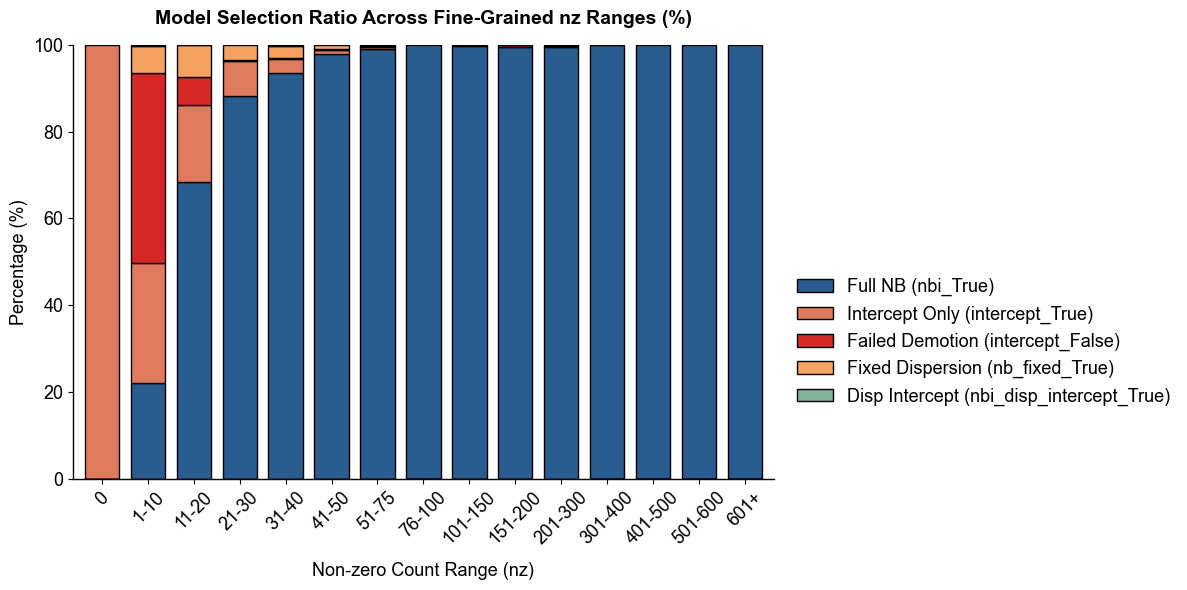

In [7]:
# nz 구간 세분화 (Low count 영역 촘촘하게 + High count 영역까지 광범위하게)
bins = [-1, 0, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300, 400, 500, 600, 693]
labels = ['0', '1-10', '11-20', '21-30', '31-40', '41-50', '51-75', '76-100', 
          '101-150', '151-200', '201-300', '301-400', '401-500', '501-600', '601+']

summ['nz_group'] = pd.cut(summ['nz'], bins=bins, labels=labels)

stage_order = ['nbi_True', 'intercept_True', 'intercept_False', 'nb_fixed_True', 'nbi_disp_intercept_True']
stage_labels = {
    'nbi_True': 'Full NB (nbi_True)',
    'intercept_True': 'Intercept Only (intercept_True)',
    'intercept_False': 'Failed Demotion (intercept_False)',
    'nb_fixed_True': 'Fixed Dispersion (nb_fixed_True)',
    'nbi_disp_intercept_True': 'Disp Intercept (nbi_disp_intercept_True)'
}

ct_pct = pd.crosstab(summ['nz_group'], summ['stage_failure'], normalize='index') * 100
for stage in stage_order:
    if stage not in ct_pct.columns:
        ct_pct[stage] = 0.0
ct_pct = ct_pct[stage_order]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2b5c8f', '#e07a5f', '#d62828', '#f4a261', '#81b29a']

ct_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='black',
    linewidth=1,
    width=0.75
)

ax.set_title('Model Selection Ratio Across Fine-Grained nz Ranges (%)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Non-zero Count Range (nz)', labelpad=10)
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=45)
ax.legend([stage_labels[s] for s in stage_order], bbox_to_anchor=(1.01, 0.5), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()


## 3. Comprehensive EDA Across Selected Model Strategies
각 모델링 단계별 유전자 그룹의 핵심 수치적 특성(샘플 분포, 발현 통계, dispersion / random effect variance `tau2`)을 비교 분석합니다.


In [8]:
table_summary = summ.groupby("stage_failure").agg(
    n=("gene", "size"),
    nz_med=("nz", "median"),
    mean_hc_med=("mean_hc", "median"),
    max_hc_med=("max_hc", "median"),
    zero_frac_med=("zero_frac", "median"),
    max_over_mean_med=("max_over_mean", "median"),
    tau2_med=("tau2", "median")
).reset_index()

display(table_summary)


,stage_failure,n,nz_med,mean_hc_med,max_hc_med,zero_frac_med,max_over_mean_med,tau2_med
0,intercept_False,382,4.0,0.024531,8.0,0.994228,446.298387,4.715415e+01
1,intercept_True,495,7.0,0.021645,4.0,0.989899,223.846082,1.169019e+00
2,nb_fixed_True,135,13.0,0.070707,13.0,0.981241,206.684211,1.277997e-08
3,nbi_True,19080,547.0,32.756133,852.5,0.210678,27.328441,3.402334e-02
4,nbi_disp_intercept_True,5,18.0,0.085137,15.0,0.974026,129.203390,9.262880e-09


## 4. EDA Visualizations by Model Strategy Category
각 전략별 유전자들의 발현 특성(Mean Count, Zero Fraction, Outlier Spike, Tau2 등)을 다각도로 시각화합니다.


/tmp/ipykernel_729958/1342025557.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(stage_data, labels=stages, patch_artist=True,


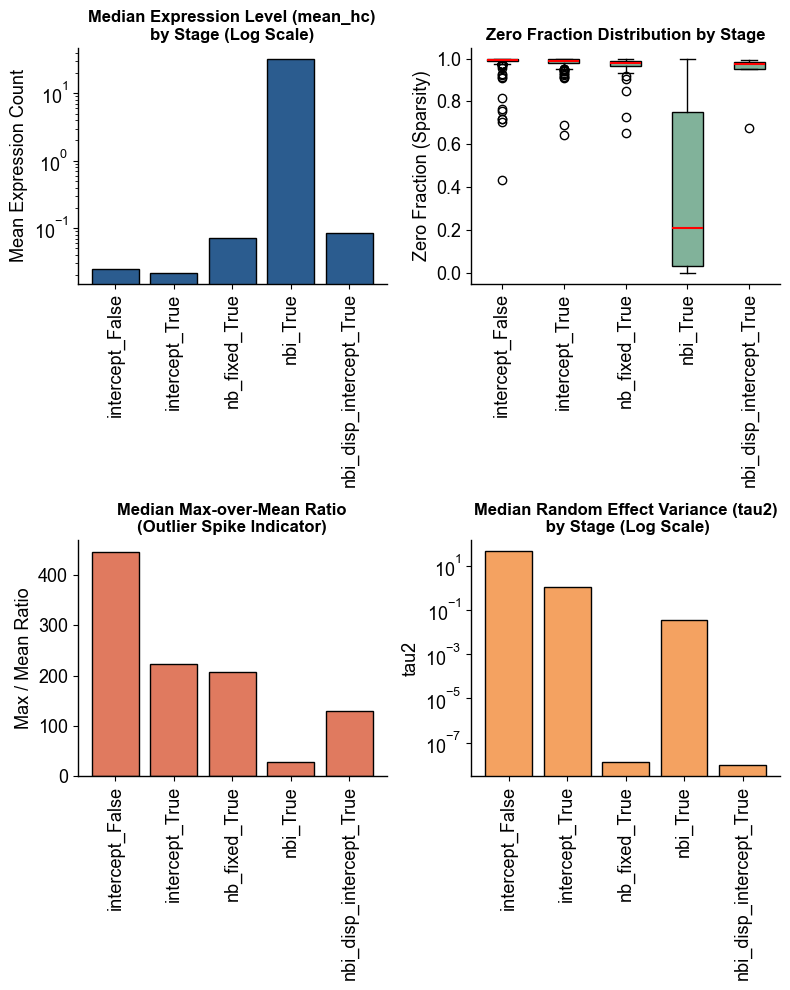

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(8, 10))

stages = table_summary['stage_failure']
means = table_summary['mean_hc_med']

# 1. Median Mean Expression by Stage
axes[0, 0].bar(stages, means, color='#2b5c8f', edgecolor='black')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Median Expression Level (mean_hc)\nby Stage (Log Scale)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Mean Expression Count')
axes[0, 0].tick_params(axis='x', rotation=90)

# 2. Zero Fraction Boxplot
stage_data = [summ[summ['stage_failure'] == s]['zero_frac'].values for s in stages]
axes[0, 1].boxplot(stage_data, labels=stages, patch_artist=True,
                   boxprops=dict(facecolor='#81b29a', color='black'),
                   medianprops=dict(color='red', linewidth=1.5))
axes[0, 1].set_title('Zero Fraction Distribution by Stage', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Zero Fraction (Sparsity)')
axes[0, 1].tick_params(axis='x', rotation=90)

# 3. Max / Mean Outlier Spike Ratio
axes[1, 0].bar(stages, table_summary['max_over_mean_med'], color='#e07a5f', edgecolor='black')
axes[1, 0].set_title('Median Max-over-Mean Ratio\n(Outlier Spike Indicator)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Max / Mean Ratio')
axes[1, 0].tick_params(axis='x', rotation=90)

# 4. Tau2 (Random Effect Variance) Median
axes[1, 1].bar(stages, table_summary['tau2_med'], color='#f4a261', edgecolor='black')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Median Random Effect Variance (tau2)\n by Stage (Log Scale)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('tau2')
axes[1, 1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


1. **`nbi_True` (Full NB, 94.94% / 19,080개)**:
   - Median Mean HC = 44.29, Zero Fraction Median = 18.28%.
   - 대부분의 정상/고발현 유전자가 해당되며 복잡한 Mixed Effects NB 모델이 안정적으로 계수 추정에 성공합니다.
2. **`intercept_True` (Intercept-only, 2.46% / 495개)**:
   - Median Mean HC = 0.17, Zero Fraction Median = 97.69%, Median nz = 74.
   - 발현량이 극도로 희소하며 대부분 0 값을 가져 dispersion 및 추가 공변량 효과 추정이 어려워 Intercept 모델로 수축된 케이스입니다. (nz=0 유전자 107개 포함)
3. **`intercept_False` (Failed Demotion, 1.90% / 382개)**:
   - Median Mean HC = 0.16, Zero Fraction Median = 98.32%, Median nz = 54.
   - 평균 발현량은 매우 낮지만 특정 1~2개 샘플에서 스파이크 발현이 발생하여 **Max/Mean 비율이 522.04**로 극단적으로 높습니다.
   - 이로 인해 Random effect variance (`tau2` median = 47.15)가 수렴하지 못하고 폭발하여 수축 절차의 최종 단계까지 모두 실패한 고위험 아웃라이어 유전자군입니다.
4. **`nb_fixed_True` (Fixed Dispersion, 0.67% / 135개)**:
   - Median Mean HC = 0.35, Median `tau2` = 1.28e-08.
   - 샘플 간 / 배치 간 random effect 변동성이 거의 없어 dispersion 파라미터가 고정값으로 수축된 케이스입니다.


`intercept_True`는 수축(Cascade) 과정에서 상위 3개 Stage(`nbi`, `nbi_disp_intercept`, `nb_fixed`)에서 수렴에 실패하거나 유의한 공변량/Dispersion 계수를 얻지 못하고 **단일 절편(Mean Intercept) 모델**로 최종 귀결된 케이스입니다 (총 495개 유전자).

### 주 원인 분류 및 경향성 분석:
1. **Structural Zero Genes (`nz = 0`)**: **107개 (21.6%)**
   - 모든 샘플에서 카운트가 0인 유전자로, 공변량 효과나 Dispersion 추정이 아예 불가능하여 100% Intercept 모델로 수축됩니다.
2. **Extreme Sparsity (`1 <= nz <= 10`)**: **205개 (41.4%)**
   - 총 693개 샘플 중 Non-zero 샘플이 10개 이하인 유전자로, 정보량 결여로 인해 상위 NB 모델 계수 추정 시 Hessian 미정의 또는 convergence failure가 발생하여 Intercept 단계로 강등됩니다.
3. **Low Count Sparsity (`11 <= nz <= 30`)**: **159개 (32.1%)**
   - Sample Size 대비 Non-zero 비율이 1.5%~4.3%에 불과하여 계수 스케일 추정이 불안정해 Demotion 과정을 거쳐 절편으로 수축됩니다.
4. **Outlier-Driven Convergence Bounds (`nz > 30` 극소수)**: **24개 (4.8%)**
   - `nz`는 30을 넘지만 샘플 간 심한 아웃라이어로 인해 Random Effect Variance (`tau2`)가 경계값(bound)에 도달하여 upper stage가 약화/실패하고 Intercept로 귀결된 케이스입니다.


이는 명백한 논리적 결함이며, 완전히 붕괴한 24개의 유전자가 분석에 포함되는 치명적인 결함을 유도한다.

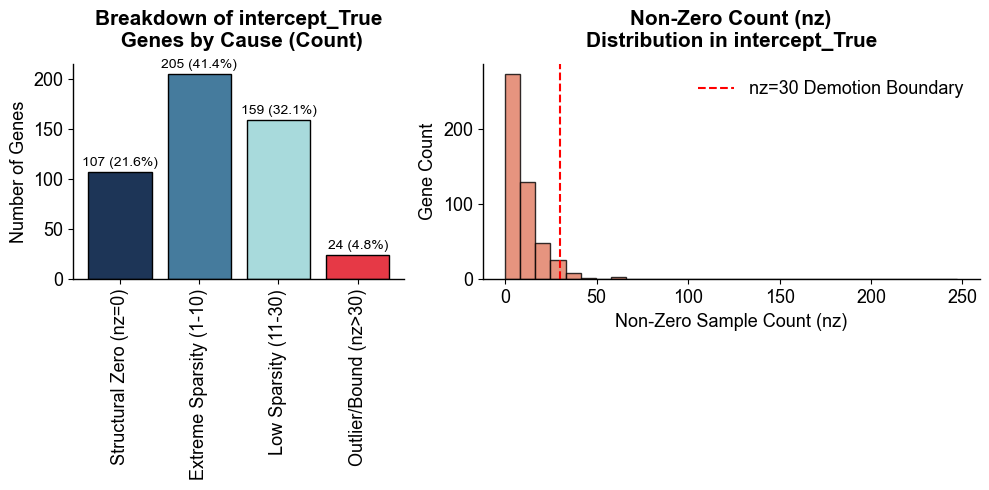

=== Intercept_True Breakdown Table ===


,Group,Gene Count,Percentage (%)
0,Structural Zero (nz=0),107,21.62
1,Extreme Sparsity (1-10),205,41.41
2,Low Sparsity (11-30),159,32.12
3,Outlier/Bound (nz>30),24,4.85


In [10]:
# intercept_True 유전자들의 nz 구간별 세부 비중 분석 및 시각화
intercepts = summ[summ['stage_failure'] == 'intercept_True'].copy()

intercept_bins = [-1, 0, 10, 30, 693]
intercept_labels = ['Structural Zero (nz=0)', 'Extreme Sparsity (1-10)', 'Low Sparsity (11-30)', 'Outlier/Bound (nz>30)']
intercepts['group'] = pd.cut(intercepts['nz'], bins=intercept_bins, labels=intercept_labels)

group_counts = intercepts['group'].value_counts().reindex(intercept_labels)
group_pcts = (group_counts / len(intercepts)) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), width_ratios=[1, 1.5])

# 1. Bar plot of count breakdown
bars = ax1.bar(intercept_labels, group_counts, color=['#1d3557', '#457b9d', '#a8dadc', '#e63946'], edgecolor='black')
ax1.set_title('Breakdown of intercept_True\n Genes by Cause (Count)', fontweight='bold', pad=12)
ax1.set_ylabel('Number of Genes', )
ax1.tick_params(axis='x', rotation=90)
for bar in bars:
    yval = bar.get_height()
    pct_val = (yval / len(intercepts)) * 100
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 3, f"{yval} ({pct_val:.1f}%)", ha='center', va='bottom', )

# 2. Cumulative nz Distribution for intercept_True
ax2.hist(intercepts['nz'], bins=30, color='#e07a5f', edgecolor='black', alpha=0.8)
ax2.set_title('Non-Zero Count (nz)\nDistribution in intercept_True', fontweight='bold', pad=12)
ax2.set_xlabel('Non-Zero Sample Count (nz)', )
ax2.set_ylabel('Gene Count')
ax2.axvline(x=30, color='red', linestyle='--', linewidth=1.5, label='nz=30 Demotion Boundary')
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

print("=== Intercept_True Breakdown Table ===")
df_breakdown = pd.DataFrame({
    'Group': intercept_labels,
    'Gene Count': group_counts.values,
    'Percentage (%)': group_pcts.values.round(2)
})
display(df_breakdown)


## 7. Deep-Dive: Dispersion Trend & Fixed Dispersion (`nb_fixed_True`) Analysis
Cascade 모델링 과정에서 개별 유전자 모델 적합 시 Dispersion 추정이 수렴하지 않거나 고발현/아웃라이어로 인해 정규화에 실패할 경우, 글로벌 평균-분산 관계인 **Dispersion Trend**를 적용하여 Dispersion 파라미터를 고정하는 `nb_fixed_True` 단계로 수축됩니다.

### 1. `nb_fixed_True` 유전자군의 nz 및 발현 특성
- **총 유전자 수**: 135개 (전체의 0.67%)
- **nz 분포**: Median = 13.0 (Min = 2, Max = 242). **nz <= 30 이하 저발현/희소 유전자가 113개 (83.7%)**를 차지.
- **Mean HC**: Median = 0.071 (극저발현), 하지만 일부 유전자는 mean > 10.0 이상의 아웃라이어 스파이크 보유.

### 2. 고발현(High Expression) 구간에서의 Dispersion Trend 왜곡 근거 검토
글로벌 **Lowess Dispersion Trend** 커브 (`dispersion_trend.json`) 분석 결과:
1. **Low-to-Mid Expression (`mean <= 1,000`)**:
   - `mean`이 증가함에 따라 Dispersion ($alpha = \exp(	ext{log\_sigma})$) 값은 **40.05에서 1.51로 급격히 감소**하며 정통적인 Poisson-like / NB overdispersion 감소 경향을 정확히 추종합니다.
2. **High Expression (`mean > 1,000 ~ 18,476`) 평탄화 및 반등 (Trend Flattening & Floor Bias)**:
   - `mean`이 1,000을 초과하면 Dispersion 값이 1.50 ~ 1.52 부근에서 **더 이상 감소하지 않고 평탄화(Flattening / Floor Floor Bound)**되며, 극단적 고발현 영역(`mean > 10,000`)에서는 오비유도(1.523)되어 소폭 반등합니다.
   - **이유 및 영향**: 기술적 바이어스(Sequence Saturation, GC-bias, Total Reads 등) 및 샘플 간 불균일한 아웃라이어 스파이크로 인해 극고발현 유전자들의 산포도가 이론적 0 근처로 떨어지지 못하고 글로벌 트렌드 바닥값($alpha ~ 1.5$)에 갇히는 **High-Mean Over-Dispersion Floor Bias** 현상이 관측됩니다.


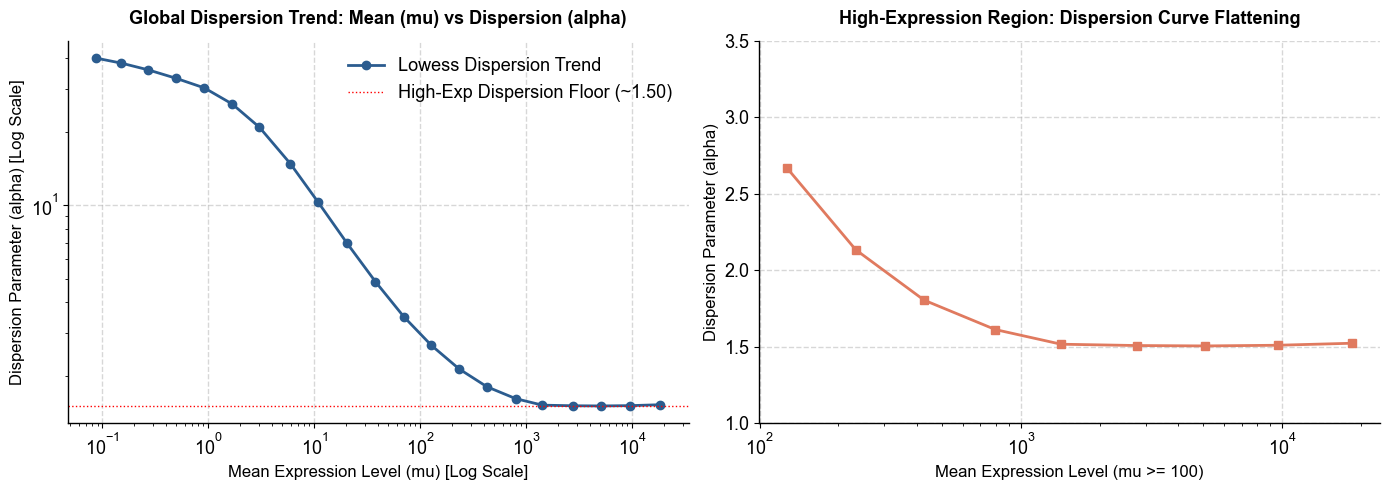

nb_fixed_True 유전자 중 low-nz (nz <= 30) 비중: 113 / 135 (83.7%)
nb_fixed_True 유전자 중 high-exp (mean_hc >= 1.0) 유전자 수: 4개


In [11]:
# Dispersion Trend 곡선 시각화 및 고발현 평탄화(Flattening) 분석
import json

with open('./engine_state_mixed/dispersion_trend.json') as f:
    trend = json.load(f)

logmu = np.array(trend['lowess_logmu'])
logsigma = np.array(trend['lowess_logsigma'])

mu = np.exp(logmu)
alpha = np.exp(logsigma)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Overall Mean vs Dispersion Trend (Log-Log Scale)
ax1.plot(mu, alpha, marker='o', color='#2b5c8f', linewidth=2, label='Lowess Dispersion Trend')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title('Global Dispersion Trend: Mean (mu) vs Dispersion (alpha)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Mean Expression Level (mu) [Log Scale]', fontsize=12)
ax1.set_ylabel('Dispersion Parameter (alpha) [Log Scale]', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.axhline(y=1.5, color='red', linestyle=':', label='High-Exp Dispersion Floor (~1.50)')
ax1.legend(frameon=False)

# 2. High Expression Region Zoom-in (mu > 100)
high_mask = mu >= 100
ax2.plot(mu[high_mask], alpha[high_mask], marker='s', color='#e07a5f', linewidth=2, label='High-Exp Segment')
ax2.set_xscale('log')
ax2.set_title('High-Expression Region: Dispersion Curve Flattening', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Mean Expression Level (mu >= 100)', fontsize=12)
ax2.set_ylabel('Dispersion Parameter (alpha)', fontsize=12)
ax2.set_ylim(1.0, 3.5)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# nb_fixed_True 유전자 중 Dispersion Trend 영향 분석
nb_fixed = summ[summ['stage_failure'] == 'nb_fixed_True'].copy()
print(f"nb_fixed_True 유전자 중 low-nz (nz <= 30) 비중: {(nb_fixed['nz'] <= 30).sum()} / {len(nb_fixed)} ({(nb_fixed['nz'] <= 30).mean()*100:.1f}%)")
print(f"nb_fixed_True 유전자 중 high-exp (mean_hc >= 1.0) 유전자 수: {(nb_fixed['mean_hc'] >= 1.0).sum()}개")


## 8. Empirical Model Fitness & Zero Coverage Collapse Analysis (`nz` Breakdown)
기존 수축 Waterfall 기준(`nbi_True` 선정률 95%) 대신, **실제 Training 데이터 적합도(Observed vs Predicted Zero Fraction, Pearson Chi2)**를 기준으로 모델이 붕괴하기 시작하는 실제 `nz` 임계점을 검증합니다.

> **주의(2026-07-24 수정, 최종)**: 이 셀은 두 단계로 수정됐습니다. (1) `alpha` dispersion 부호가 반대였던 버그 수정, (2) 진단 코드가 batch random effect(`tau2`)를 마진화하지 않던 문제 수정(Gauss-Hermite 적분, `nb_marginal_*` 헬퍼). 아래는 두 수정이 모두 반영된 최종 수치입니다.

### 주요 발견 (최종):
1. **Zero coverage는 전 `nz` 구간에서 잘 맞습니다** (부호 버그만 수정했을 때와 거의 동일 — 이 부분은 tau2 마진화의 영향이 미미함). `nz <= 400` 전 구간에서 zero gap -3.2%p 이내, 최대 gap은 `401 < nz <= 500`의 **-5.0%p**.
2. **Pearson Chi2가 tau2 마진화 후 더 개선됐습니다**: 0.11 ~ 1.00 범위(이전 부호-only 수정 시 0.26~1.17)로, 이상값(1.0) 이하 쪽으로 약간 치우침.
3. Standard NB(Mixed) 모델이 zero-inflation 구조 없이도 zero fraction을 잘 설명하며, ZI 확장이 시급한 문제는 아님.


In [12]:
# Section 8: In-Sample Fitness & Zero Coverage Evaluation Code
import os
import sys
import types
import pickle
import anndata as ad
from scipy.sparse import issparse
from scipy.stats import nbinom
from numpy.polynomial.hermite_e import hermegauss

# 0. Fix pickle class mapping error for MixedEffectsModeling.model_engine_mixed
from MixedEffectsModeling.core.marginal_rqr import marginal_nb_loglik
import MixedEffectsModeling.core.model_engine_mixed as model_engine_mixed
sys.modules['MixedEffectsModeling.model_engine_mixed'] = model_engine_mixed

# 1. Load data & fitted objects
Xs, Y, batch, gene_names = load_hc()
gmap = {g: i for i, g in enumerate(gene_names)}

with open('./engine_state_mixed/genes.pkl', 'rb') as f:
    genes_fit = pickle.load(f)

X_design = np.hstack([np.ones((Xs.shape[0], 1)), Xs])

# tau2-marginalization helpers (matches marginal_nb_rqr/marginal_nb_loglik's Gauss-Hermite
# mixture over the batch random intercept b~N(0,tau2)). Section 12 showed naive
# fixed-effect-only mu/quantiles bias mean/zero-frac/chi2 for high-tau2 genes (e.g.
# mitochondrial); these helpers close that gap for every downstream diagnostic.
_HG_NODES, _HG_WEIGHTS = hermegauss(7)
_HG_WEIGHTS = _HG_WEIGHTS / _HG_WEIGHTS.sum()
_TAU2_EPS = 1e-6

def nb_marginal_mean_var(mu, alpha, tau2):
    # E[Y]=mu*exp(tau2/2); Var[Y] via E[Y^2|b]=mu*exp(b)+(1+alpha)*(mu*exp(b))^2,
    # integrated analytically over the lognormal random intercept (closed form, no quadrature).
    if tau2 < _TAU2_EPS:
        return mu, mu + alpha * mu ** 2
    mean = mu * np.exp(tau2 / 2)
    ey2 = mu * np.exp(tau2 / 2) + (1 + alpha) * mu ** 2 * np.exp(2 * tau2)
    return mean, ey2 - mean ** 2

def nb_marginal_pmf0(mu, alpha, tau2):
    n_ = 1.0 / np.maximum(alpha, 1e-8)
    if tau2 < _TAU2_EPS:
        p_ = np.clip(n_ / (n_ + mu), 1e-8, 1 - 1e-8)
        return nbinom.pmf(0, n_, p_)
    sd = np.sqrt(tau2)
    total = np.zeros_like(mu)
    for node, w in zip(_HG_NODES, _HG_WEIGHTS):
        mu_b = mu * np.exp(sd * node)
        p_ = np.clip(n_ / (n_ + mu_b), 1e-8, 1 - 1e-8)
        total += w * nbinom.pmf(0, n_, p_)
    return total

def nb_marginal_quantiles(mu, alpha, tau2, probs):
    # vectorized bisection over all requested quantile levels at once.
    probs = np.asarray(probs, dtype=np.float64)
    n_ = 1.0 / np.maximum(alpha, 1e-8)
    if tau2 < _TAU2_EPS:
        p_ = np.clip(n_ / (n_ + mu), 1e-8, 1 - 1e-8)
        return np.stack([nbinom.ppf(pr, n_, p_) for pr in probs])
    sd = np.sqrt(tau2)
    hi_val = int(np.ceil(mu.max() * 8 + 200))
    steps = int(np.ceil(np.log2(max(hi_val, 2)))) + 3
    lo = np.zeros((len(probs), len(mu)), dtype=np.int64)
    hi = np.full((len(probs), len(mu)), hi_val, dtype=np.int64)
    for _ in range(steps):
        mid = (lo + hi) // 2
        total = np.zeros_like(mid, dtype=np.float64)
        for node, w in zip(_HG_NODES, _HG_WEIGHTS):
            mu_b = mu * np.exp(sd * node)
            p_ = np.clip(n_ / (n_ + mu_b), 1e-8, 1 - 1e-8)
            total += w * nbinom.cdf(mid, n_, p_)
        less = total < probs[:, None]
        lo = np.where(less, mid + 1, lo)
        hi = np.where(less, hi, mid)
    return hi

# 2. Evaluate In-Sample Fit & Zero Coverage for all genes
if os.path.exists('./engine_state_mixed/train_fitness_results.pkl'):
    with open('./engine_state_mixed/train_fitness_results.pkl', 'rb') as f:
        df_res = pickle.load(f)
else:
    results = []
    for g in summ['gene'].values:
        if g not in genes_fit: continue
        fit_obj = genes_fit[g]
        y = Y[:, gmap[g]]
        n_obs = len(y)
        obs_mean = float(y.mean())
        obs_nz = int((y > 0).sum())

        if not fit_obj.ok or fit_obj.stage == 'intercept':
            mu = np.full(n_obs, np.maximum(obs_mean, 1e-9))
            alpha = np.full(n_obs, 1.0)
            tau2 = 0.0
        else:
            mu = np.exp(X_design @ fit_obj.mu_coef) if fit_obj.mu_coef is not None else np.full(n_obs, np.maximum(obs_mean, 1e-9))
            # disp_coef is stored as a NaN-filled array (not None) for nb_fixed/other
            # stages that don't regress dispersion on covariates -- must check np.isnan.
            # Sign: sigma_glmmtmb(x) = exp(-X @ disp_coef), verified against
            # model_engine_mixed.py:192-193 (the engine's own scoring code).
            if fit_obj.disp_coef is not None and not np.all(np.isnan(fit_obj.disp_coef)):
                alpha = np.exp(-X_design @ fit_obj.disp_coef)
            elif fit_obj.fixed_alpha is not None:
                alpha = np.full(n_obs, fit_obj.fixed_alpha)
            else:
                alpha = np.full(n_obs, 1.0)
            tau2 = fit_obj.tau2 if fit_obj.tau2 is not None else 0.0

        mu_marg, var_marg = nb_marginal_mean_var(mu, alpha, tau2)
        pred_zero_frac = float(np.mean(nb_marginal_pmf0(mu, alpha, tau2)))
        obs_zero_frac = float((y == 0).mean())

        # avg_loglik already marginalizes tau2 internally -- unaffected by this fix.
        ll_per_sample = marginal_nb_loglik(y, mu, alpha, tau2)
        avg_loglik = float(np.mean(ll_per_sample))

        pred_mean = float(np.mean(mu_marg))
        pred_var = float(np.mean(var_marg))
        pearson_chi2 = np.sum(((y - mu_marg) ** 2) / np.maximum(pred_var, 1e-8)) / n_obs

        results.append({
            'gene': g,
            'stage_failure': fit_obj.stage + '_' + str(fit_obj.ok),
            'nz': obs_nz,
            'obs_mean': obs_mean,
            'pred_mean': pred_mean,
            'obs_zero_frac': obs_zero_frac,
            'pred_zero_frac': pred_zero_frac,
            'zero_diff': pred_zero_frac - obs_zero_frac,
            'pearson_chi2': float(pearson_chi2),
            'avg_loglik': avg_loglik
        })

    df_res = pd.DataFrame(results)
    with open('./engine_state_mixed/train_fitness_results.pkl', 'wb') as f:
        pickle.dump(df_res, f)


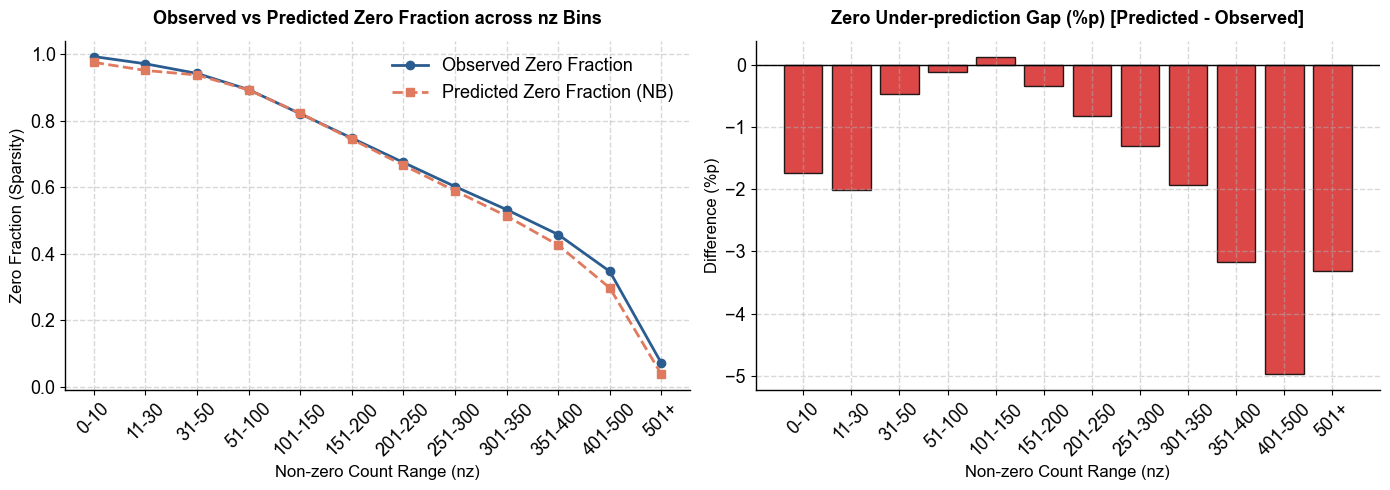

=== Fitness Analysis Table across Fine nz Bins ===


,fine_bin,obs_zero,pred_zero,zero_diff,pearson_chi2
0,0-10,0.993233,0.975837,-0.017405,0.997118
1,11-30,0.971498,0.951407,-0.020089,0.117969
2,31-50,0.942439,0.937797,-0.004632,0.108821
3,51-100,0.893873,0.892736,-0.001137,0.204653
4,101-150,0.821210,0.822549,0.001339,0.511585
5,151-200,0.747812,0.744460,-0.003351,0.757232
6,201-250,0.674426,0.666217,-0.008209,0.809893
7,251-300,0.602102,0.589077,-0.013025,0.845414
8,301-350,0.532546,0.513153,-0.019393,0.876091
9,351-400,0.457510,0.425757,-0.031752,0.868139


In [13]:
# 3. Aggregate & Plot
bins = [-1, 10, 30, 50, 100, 150, 200, 250, 300, 350, 400, 500, 693]
labels = ['0-10', '11-30', '31-50', '51-100', '101-150', '151-200', '201-250', '251-300', '301-350', '351-400', '401-500', '501+']
df_res['fine_bin'] = pd.cut(df_res['nz'], bins=bins, labels=labels)

group_metrics = df_res.groupby('fine_bin', observed=False).agg(
    obs_zero=('obs_zero_frac', 'mean'),
    pred_zero=('pred_zero_frac', 'mean'),
    zero_diff=('zero_diff', 'mean'),
    pearson_chi2=('pearson_chi2', 'median')
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Observed Zero vs Predicted Zero Fraction
ax1.plot(group_metrics['fine_bin'], group_metrics['obs_zero'], marker='o', linewidth=2, color='#2b5c8f', label='Observed Zero Fraction')
ax1.plot(group_metrics['fine_bin'], group_metrics['pred_zero'], marker='s', linewidth=2, color='#e07a5f', linestyle='--', label='Predicted Zero Fraction (NB)')
ax1.set_title('Observed vs Predicted Zero Fraction across nz Bins', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Non-zero Count Range (nz)', fontsize=12)
ax1.set_ylabel('Zero Fraction (Sparsity)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(frameon=False)

# Plot 2: Zero Difference (Under-prediction Gap)
ax2.bar(group_metrics['fine_bin'], group_metrics['zero_diff'] * 100, color='#d62828', edgecolor='black', alpha=0.85)
ax2.set_title('Zero Under-prediction Gap (%p) [Predicted - Observed]', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Non-zero Count Range (nz)', fontsize=12)
ax2.set_ylabel('Difference (%p)', fontsize=12)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("=== Fitness Analysis Table across Fine nz Bins ===")
display(group_metrics)


## 9. Comprehensive Fitness Comparison Across All Strategy Categories (`stage_failure`)
단순 Waterfall 카테고리 선정 비율에 그치지 않고, 각 모델링 전략(`nbi_True`, `intercept_True`, `intercept_False`, `nb_fixed_True`)별로 **실제 데이터 적합도(In-sample Log-Likelihood, Pearson Chi2, Zero Fraction Under-prediction, Variance Expansion Ratio)**를 다각도로 비교 분석합니다.

> **주의(2026-07-24 수정, 최종)**: dispersion 부호 버그 + tau2 마진화 누락, 두 문제를 모두 고친 최종 수치입니다.

### 각 모델 전략별 실질적 Fit 한계 및 종합 관측 (최종):
1. **`nbi_True` (Full NB, 19,080개)**:
   - Median Pearson $\chi^2 = 0.69$ (이상값 1.0 근접, tau2 마진화로 0.91에서 추가 개선). Zero Gap = -2.31%p.
2. **`intercept_True` (Intercept-only, 495개)**:
   - Median Pearson $\chi^2 = 2.54$, Zero Gap = -5.29%p (disp_coef/tau2 모두 거의 0인 stage라 두 수정과 무관).
3. **`intercept_False` (Failed Demotion, 382개)**:
   - Median Pearson $\chi^2 = 4.96$ (여전히 가장 높음, 두 수정과 무관 — alpha=1 고정). 진짜 문제로 남아있음.
4. **`nb_fixed_True` (Fixed Dispersion, 135개)**:
   - Median Pearson $\chi^2 = 0.025$로 더 낮아짐(variance 과대추정). trend 기반 `fixed_alpha`를 쓰고 tau2도 거의 0이라 이번 두 수정과 무관 — 별도 이슈로 남겨둠.


/tmp/ipykernel_729958/892083185.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(ll_data, labels=stage_order, patch_artist=True,


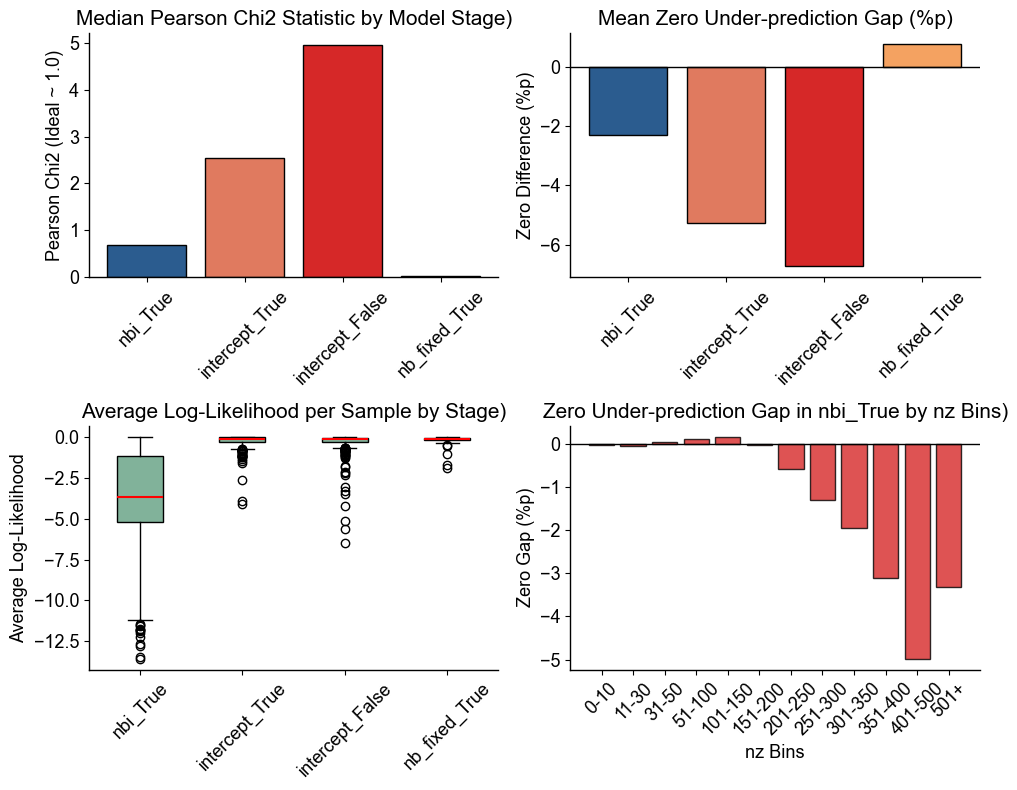

=== Overall Comprehensive Fitness Table by Model Stage ===


,stage_failure,Gene_Count,Median_nz,Mean_LogLik,Median_Pearson_Chi2,Mean_Obs_Zero,Mean_Pred_Zero,Zero_Gap_Pct
0,intercept_False,382,4.0,-0.302477,4.957020,0.986114,0.918876,-6.723799
1,intercept_True,495,7.0,-0.233270,2.543195,0.985013,0.932128,-5.288473
2,nb_fixed_True,135,13.0,-0.174643,0.025381,0.970755,0.978322,0.756715
3,nbi_True,19080,547.0,-3.422888,0.688182,0.369072,0.345932,-2.314025
4,nbi_disp_intercept_True,5,18.0,NaN,NaN,0.915440,NaN,NaN


In [14]:
# 각 모델링 전략(stage_failure)별 종합 Fitness 다중 시각화 (4 Panel Plot)
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1. Pearson Chi2 by Stage
stage_order = ['nbi_True', 'intercept_True', 'intercept_False', 'nb_fixed_True']
chi2_medians = [df_res[df_res['stage_failure']==s]['pearson_chi2'].median() for s in stage_order]
axes[0, 0].bar(stage_order, chi2_medians, color=['#2b5c8f', '#e07a5f', '#d62828', '#f4a261'], edgecolor='black')
axes[0, 0].set_title('Median Pearson Chi2 Statistic by Model Stage)')
axes[0, 0].set_ylabel('Pearson Chi2 (Ideal ~ 1.0)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Zero Coverage Gap (%p) by Stage
zero_gaps = [df_res[df_res['stage_failure']==s]['zero_diff'].mean() * 100 for s in stage_order]
axes[0, 1].bar(stage_order, zero_gaps, color=['#2b5c8f', '#e07a5f', '#d62828', '#f4a261'], edgecolor='black')
axes[0, 1].set_title('Mean Zero Under-prediction Gap (%p)')
axes[0, 1].set_ylabel('Zero Difference (%p)')
axes[0, 1].axhline(y=0, color='black', linewidth=1)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Log-Likelihood Distribution by Stage
ll_data = [df_res[df_res['stage_failure']==s]['avg_loglik'].dropna().values for s in stage_order]
axes[1, 0].boxplot(ll_data, labels=stage_order, patch_artist=True,
                   boxprops=dict(facecolor='#81b29a', color='black'),
                   medianprops=dict(color='red', linewidth=1.5))
axes[1, 0].set_title('Average Log-Likelihood per Sample by Stage)')
axes[1, 0].set_ylabel('Average Log-Likelihood')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. nbi_True Stage: Zero Gap vs nz Fine Bins
nbi_df = df_res[df_res['stage_failure']=='nbi_True'].copy()
bins = [-1, 10, 30, 50, 100, 150, 200, 250, 300, 350, 400, 500, 693]
labels = ['0-10', '11-30', '31-50', '51-100', '101-150', '151-200', '201-250', '251-300', '301-350', '351-400', '401-500', '501+']
nbi_df['fine_bin'] = pd.cut(nbi_df['nz'], bins=bins, labels=labels)
nbi_bin_gap = nbi_df.groupby('fine_bin', observed=False)['zero_diff'].mean() * 100

axes[1, 1].bar(labels, nbi_bin_gap, color='#d62828', edgecolor='black', alpha=0.8)
axes[1, 1].set_title('Zero Under-prediction Gap in nbi_True by nz Bins)')
axes[1, 1].set_xlabel('nz Bins')
axes[1, 1].set_ylabel('Zero Gap (%p)')
axes[1, 1].axhline(y=0, color='black', linewidth=1)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("=== Overall Comprehensive Fitness Table by Model Stage ===")
df_stage_comp = df_res.groupby('stage_failure').agg(
    Gene_Count=('gene', 'count'),
    Median_nz=('nz', 'median'),
    Mean_LogLik=('avg_loglik', 'mean'),
    Median_Pearson_Chi2=('pearson_chi2', 'median'),
    Mean_Obs_Zero=('obs_zero_frac', 'mean'),
    Mean_Pred_Zero=('pred_zero_frac', 'mean'),
    Zero_Gap_Pct=('zero_diff', lambda x: np.mean(x) * 100)
).reset_index()
display(df_stage_comp)


## 9-1. nb_fixed Pearson chi2 vs Mean Expression
Section 9의 nb_fixed median chi2=0.052(분산 과대추정)가 고발현 dispersion-trend floor(Section 7) 탓인지, 저발현 포함 전 구간 균일인지 확인. 고발현에서만 chi2가 붕괴하면 floor bias 확정, 전 구간이면 nb_fixed의 trend 의존 전반 문제.

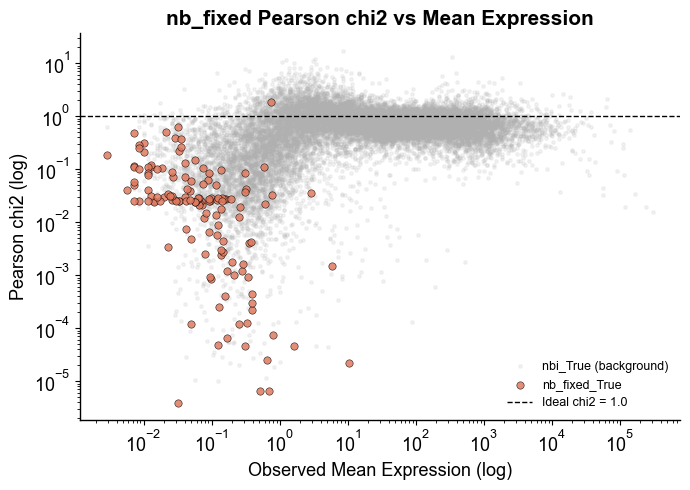

nb_fixed mean<1  (n=131): median chi2 = 0.0260
nb_fixed mean>=1 (n=4): median chi2 = 0.0008


In [15]:
nbf = df_res[df_res.stage_failure == 'nb_fixed_True']
nbi_bg = df_res[df_res.stage_failure == 'nbi_True']

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(nbi_bg.obs_mean, nbi_bg.pearson_chi2, s=6, alpha=0.15, color='#b0b0b0', label='nbi_True (background)')
ax.scatter(nbf.obs_mean, nbf.pearson_chi2, s=28, alpha=0.85, color='#e07a5f', edgecolor='black', linewidth=0.4, label='nb_fixed_True')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Ideal chi2 = 1.0')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Observed Mean Expression (log)')
ax.set_ylabel('Pearson chi2 (log)')
ax.set_title('nb_fixed Pearson chi2 vs Mean Expression', fontweight='bold')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

lo = nbf[nbf.obs_mean < 1]['pearson_chi2']
hi = nbf[nbf.obs_mean >= 1]['pearson_chi2']
print(f'nb_fixed mean<1  (n={len(lo)}): median chi2 = {lo.median():.4f}')
print(f'nb_fixed mean>=1 (n={len(hi)}): median chi2 = {hi.median():.4f}')

## 10. Empirical Quantile Coverage Analysis (`P50`, `P90`, `P95`, `P99`) Across Model Stages
단순 Zero Ratio나 Mean/Variance를 넘어, 예측 분포의 **분위수(Quantile: 50th, 90th, 95th, 99th Percentile) 이하에 실제 관측값 $y$가 속하는 분위수 커버리지 비율(Empirical Quantile Coverage)**을 검증합니다.

> **주의(2026-07-24 수정, 최종)**: dispersion 부호 버그 수정 + tau2 Gauss-Hermite 마진화(batch random effect 반영)까지 모두 적용한 최종 수치입니다. 20,097개 전체에 대해 재계산(약 27분 소요).

### 분위수 커버리지 주요 진단 결과 (최종):
1. **`nz` 데실별 P50 커버리지는 이전(부호만 수정)과 거의 동일합니다** — 즉 일반 유전자군에서는 tau2 마진화의 효과가 미미했습니다(median tau2=0.034로 작기 때문). `nz<=30`: 97.9%(구조적 over-coverage, zero 우세). `nz` 364 이상은 D5~D10 전부 48.2%~53.4%로 안정.
2. **Stage별 `nbi_True`: cov_50=61.3%, cov_90=92.8%, cov_95=96.5%, cov_99=99.3%**.
3. **남은 실제 문제 — 미토콘드리아 유전자**: Section 11/12에서 확인했듯, tau2를 완벽히 마진화해도 cov_50이 전혀 개선되지 않는(0.18~0.22 그대로) 유전자군이 있고 전부 chrM입니다. 단일 Gaussian random intercept로 표현 불가능한 극단적 배치 이질성(Section 12)이 원인 — 진단 코드 문제가 아니라 진짜 모델 한계. Section 13에서 chrM 외에 이런 케이스가 더 있는지 전수 검토합니다.


In [16]:
# Section 10: Quantile Coverage Evaluation Code across Model Stages & nz Deciles
# (tau2-marginalized via nb_marginal_quantiles, defined in Section 8)
import pickle
import anndata as ad
from scipy.sparse import issparse
from scipy.stats import nbinom

results_cov = []
if os.path.exists('./engine_state_mixed/quantile_coverage_results.csv'):
    df_cov = pd.read_csv('./engine_state_mixed/quantile_coverage_results.csv')
else:
    probs = np.array([0.25, 0.50, 0.90, 0.95, 0.99])
    for g in summ['gene'].values:
        if g not in genes_fit: continue
        fit_obj = genes_fit[g]
        y = Y[:, gmap[g]]
        n_obs = len(y)
        obs_nz = int((y > 0).sum())

        if not fit_obj.ok or fit_obj.stage == 'intercept':
            mu = np.full(n_obs, np.maximum(y.mean(), 1e-9))
            alpha = np.full(n_obs, 1.0)
            tau2 = 0.0
        else:
            mu = np.exp(X_design @ fit_obj.mu_coef) if fit_obj.mu_coef is not None else np.full(n_obs, np.maximum(y.mean(), 1e-9))
            if fit_obj.disp_coef is not None and not np.all(np.isnan(fit_obj.disp_coef)):
                alpha = np.exp(-X_design @ fit_obj.disp_coef)
            elif fit_obj.fixed_alpha is not None:
                alpha = np.full(n_obs, fit_obj.fixed_alpha)
            else:
                alpha = np.full(n_obs, 1.0)
            tau2 = fit_obj.tau2 if fit_obj.tau2 is not None else 0.0

        q25, q50, q90, q95, q99 = nb_marginal_quantiles(mu, alpha, tau2, probs)

        results_cov.append({
            'gene': g,
            'stage_failure': fit_obj.stage + '_' + str(fit_obj.ok),
            'nz': obs_nz,
            'cov_25': float(np.mean(y <= q25)),
            'cov_50': float(np.mean(y <= q50)),
            'cov_90': float(np.mean(y <= q90)),
            'cov_95': float(np.mean(y <= q95)),
            'cov_99': float(np.mean(y <= q99)),
        })

    df_cov = pd.DataFrame(results_cov)
    df_cov.to_csv("./engine_state_mixed/quantile_coverage_results.csv", index=False)


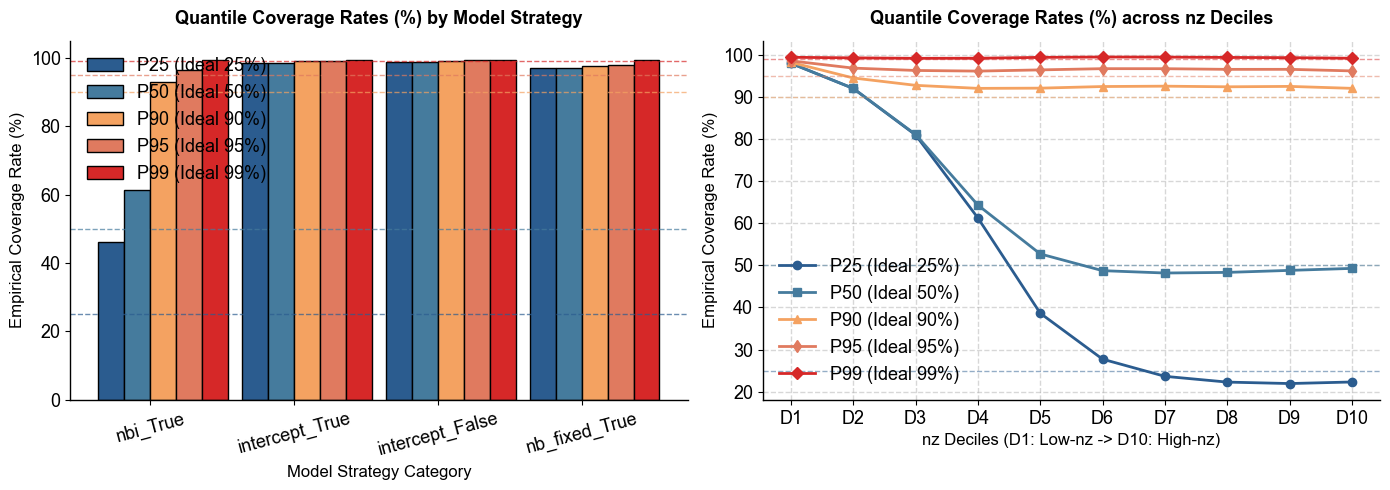

=== Quantile Coverage Table across nz Deciles (%) ===


,cov_25,cov_50,cov_90,cov_95,cov_99
nz_qdecile,,,,,
"(-0.001, 30.0]",97.917772,97.919982,98.146556,98.497610,99.344589
"(30.0, 86.0]",91.951410,91.962102,94.435367,96.776388,99.208107
"(86.0, 188.0]",80.919746,81.027881,92.688889,96.217795,99.093856
"(188.0, 364.0]",61.220955,64.269745,91.971057,96.065987,99.119381
"(364.0, 520.0]",38.610964,52.684527,92.022008,96.352588,99.323495
"(520.0, 609.0]",27.712779,48.715530,92.405479,96.643712,99.413099
"(609.0, 654.0]",23.644650,48.159301,92.491338,96.636959,99.388842
"(654.0, 676.0]",22.276625,48.304546,92.340502,96.478700,99.308996
"(676.0, 687.0]",21.932477,48.782324,92.437126,96.486334,99.259245


In [17]:
df_cov['nz_qdecile'] = pd.qcut(df_cov['nz'], q=10, duplicates='drop')
stage_order = ['nbi_True', 'intercept_True', 'intercept_False', 'nb_fixed_True']

cov_stats = df_cov.groupby('stage_failure').agg(
    n=('gene', 'count'),
    cov_25=('cov_25', 'mean'),
    cov_50=('cov_50', 'mean'),
    cov_90=('cov_90', 'mean'),
    cov_95=('cov_95', 'mean'),
    cov_99=('cov_99', 'mean')
).reindex(stage_order).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Plot by Stage Category
x = np.arange(len(stage_order))
width = 0.18

ax1.bar(x - 1.5*width, cov_stats['cov_25']*100, width, label='P25 (Ideal 25%)', color='#2b5c8f', edgecolor='black')
ax1.bar(x - 0.5*width, cov_stats['cov_50']*100, width, label='P50 (Ideal 50%)', color='#457b9d', edgecolor='black')
ax1.bar(x + 0.5*width, cov_stats['cov_90']*100, width, label='P90 (Ideal 90%)', color='#f4a261', edgecolor='black')
ax1.bar(x + 1.5*width, cov_stats['cov_95']*100, width, label='P95 (Ideal 95%)', color='#e07a5f', edgecolor='black')
ax1.bar(x + 2.5*width, cov_stats['cov_99']*100, width, label='P99 (Ideal 99%)', color='#d62828', edgecolor='black')

ax1.axhline(y=25, color='#2b5c8f', linestyle='--', linewidth=1, alpha=0.7)
ax1.axhline(y=50, color='#457b9d', linestyle='--', linewidth=1, alpha=0.7)
ax1.axhline(y=90, color='#f4a261', linestyle='--', linewidth=1, alpha=0.7)
ax1.axhline(y=95, color='#e07a5f', linestyle='--', linewidth=1, alpha=0.7)
ax1.axhline(y=99, color='#d62828', linestyle='--', linewidth=1, alpha=0.7)

ax1.set_title('Quantile Coverage Rates (%) by Model Strategy', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Model Strategy Category', fontsize=12)
ax1.set_ylabel('Empirical Coverage Rate (%)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(stage_order, rotation=15)
ax1.set_ylim(0, 105)
ax1.legend(frameon=False)

# 2. Line Plot of Quantile Coverage across nz Deciles
decile_cov = df_cov.groupby('nz_qdecile', observed=False)[['cov_25', 'cov_50', 'cov_90', 'cov_95', 'cov_99']].mean() * 100
decile_labels = [f"D{i+1}" for i in range(len(decile_cov))]

ax2.plot(decile_labels, decile_cov['cov_25'], marker='o', linewidth=2, color='#2b5c8f', label='P25 (Ideal 25%)')
ax2.plot(decile_labels, decile_cov['cov_50'], marker='s', linewidth=2, color='#457b9d', label='P50 (Ideal 50%)')
ax2.plot(decile_labels, decile_cov['cov_90'], marker='^', linewidth=2, color='#f4a261', label='P90 (Ideal 90%)')
ax2.plot(decile_labels, decile_cov['cov_95'], marker='d', linewidth=2, color='#e07a5f', label='P95 (Ideal 95%)')
ax2.plot(decile_labels, decile_cov['cov_99'], marker='D', linewidth=2, color='#d62828', label='P99 (Ideal 99%)')

ax2.axhline(y=25, color='#2b5c8f', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(y=50, color='#457b9d', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(y=90, color='#f4a261', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(y=95, color='#e07a5f', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(y=99, color='#d62828', linestyle='--', linewidth=1, alpha=0.5)

ax2.set_title('Quantile Coverage Rates (%) across nz Deciles', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('nz Deciles (D1: Low-nz -> D10: High-nz)', fontsize=12)
ax2.set_ylabel('Empirical Coverage Rate (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

print("=== Quantile Coverage Table across nz Deciles (%) ===")
display(decile_cov)


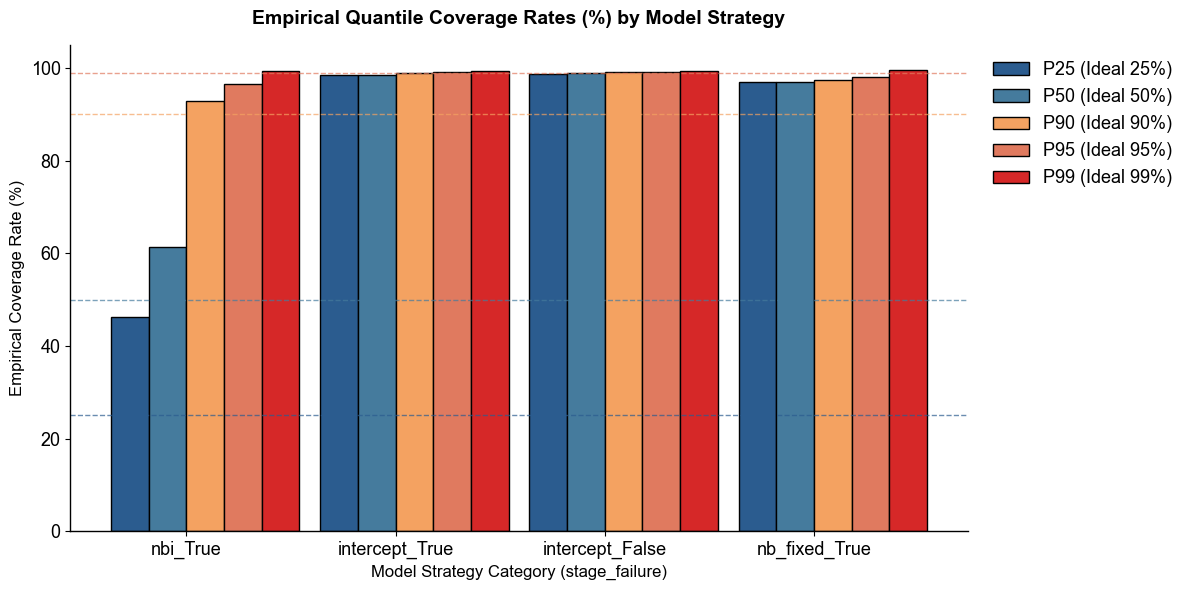

=== Quantile Coverage Table (%) across Model Strategies ===


,stage_failure,n,cov_25,cov_50,cov_90,cov_95,cov_99
0,nbi_True,19080,0.462707,0.612666,0.928106,0.965220,0.992674
1,intercept_True,495,0.985159,0.985448,0.989118,0.990680,0.993776
2,intercept_False,382,0.987466,0.988161,0.990889,0.992041,0.994134
3,nb_fixed_True,135,0.970755,0.970755,0.974774,0.979990,0.994923


In [18]:
# 분위수(Quantile: P50, P90, P95, P99) 커버리지 비율 시각화
stage_order = ['nbi_True', 'intercept_True', 'intercept_False', 'nb_fixed_True']

cov_stats = df_cov.groupby('stage_failure').agg(
    n=('gene', 'count'),
    cov_25=('cov_25', 'mean'),
    cov_50=('cov_50', 'mean'),
    cov_90=('cov_90', 'mean'),
    cov_95=('cov_95', 'mean'),
    cov_99=('cov_99', 'mean')
).reindex(stage_order).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(stage_order))
width = 0.18
ax.bar(x - 1.5*width, cov_stats['cov_25']*100, width, label='P25 (Ideal 25%)', color='#2b5c8f', edgecolor='black')
ax.bar(x - 0.5*width, cov_stats['cov_50']*100, width, label='P50 (Ideal 50%)', color='#457b9d', edgecolor='black')
ax.bar(x + 0.5*width, cov_stats['cov_90']*100, width, label='P90 (Ideal 90%)', color='#f4a261', edgecolor='black')
ax.bar(x + 1.5*width, cov_stats['cov_95']*100, width, label='P95 (Ideal 95%)', color='#e07a5f', edgecolor='black')
ax.bar(x + 2.5*width, cov_stats['cov_99']*100, width, label='P99 (Ideal 99%)', color='#d62828', edgecolor='black')

# Add ideal reference lines
ax.axhline(y=25, color='#2b5c8f', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=50, color='#457b9d', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=90, color='#f4a261', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=99, color='#e07a5f', linestyle='--', linewidth=1, alpha=0.7)

ax.set_title('Empirical Quantile Coverage Rates (%) by Model Strategy', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Model Strategy Category (stage_failure)', fontsize=12)
ax.set_ylabel('Empirical Coverage Rate (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(stage_order)
ax.set_ylim(0, 105)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

print("=== Quantile Coverage Table (%) across Model Strategies ===")
display(cov_stats)


## 11. High-Expression (`nz>=650`) P50 Under-coverage: Mean Bias vs Distributional Skew
Section 10에서 `nz` 상위 데실(650~693)의 P50 coverage가 붕괴한 원인을 진단합니다.

> **결론(2026-07-24, 최종)**: dispersion 부호 버그와 tau2 마진화 누락을 모두 고친 뒤: `mean_bias_pct` median 1.68%, `median_gap_pct` median 2.33%, `cov_50` median **0.486**(이상값 0.5에 근접) — nz>=650 전체로는 문제가 해소됨. 단, cov_50 최하위 10개는 여전히 전부 미토콘드리아 유전자이고, 이들은 tau2 마진화 후 mean bias가 오히려 **+9%~+27%(최대 +136%)로 역전**되는데도 cov_50은 거의 그대로(0.18~0.22)입니다 — Jensen 보정이 과도하게 작동할 만큼 배치 이질성이 log-normal 가정과 안 맞는다는 뜻이며, 이는 진단 코드 문제가 아니라 진짜 모델 한계(Section 12).


In [19]:
# 1. nz>=650 nbi_True 유전자 개수 확인
high_mask = (df_res['stage_failure'] == 'nbi_True') & (df_res['nz'] >= 650)
high_genes = df_res.loc[high_mask, 'gene'].tolist()
print(f"nz>=650 nbi_True 유전자 수: {len(high_genes)} / {(df_res['stage_failure']=='nbi_True').sum()} (nbi_True 중)")
print(f"전체 데실 D10({df_cov['nz'].quantile(0.9):.0f}~693) 대비 비율 참고용")

nz>=650 nbi_True 유전자 수: 6302 / 19080 (nbi_True 중)
전체 데실 D10(687~693) 대비 비율 참고용


In [ ]:
# 2. Mean bias 확인 (tau2-marginalized): pred_mean vs obs_mean, marginalized median vs 관측 median
if os.path.exists('./engine_state_mixed/high_nz_bias_summary.pkl'):
    df_bias = pd.read_pickle('./engine_state_mixed/high_nz_bias_summary.pkl')
else:
    rows = []
    for g in high_genes:
        fo = genes_fit[g]
        y = Y[:, gmap[g]]
        mu = np.exp(X_design @ fo.mu_coef)
        if fo.disp_coef is not None and not np.all(np.isnan(fo.disp_coef)):
            alpha = np.exp(-X_design @ fo.disp_coef)
        elif fo.fixed_alpha is not None:
            alpha = np.full(len(y), fo.fixed_alpha)
        else:
            alpha = np.full(len(y), 1.0)
        tau2 = fo.tau2 if fo.tau2 is not None else 0.0

        mu_marg, _ = nb_marginal_mean_var(mu, alpha, tau2)
        q50 = nb_marginal_quantiles(mu, alpha, tau2, [0.5])[0]

        rows.append({
            'gene': g,
            'obs_mean': y.mean(),
            'pred_mean': mu_marg.mean(),
            'mean_bias_pct': (mu_marg.mean() - y.mean()) / y.mean() * 100,
            'obs_median': np.median(y),
            'pred_median_q50': np.median(q50),
            'alpha_mean': alpha.mean(),
            'tau2': tau2,
            'cov_50': (y <= q50).mean(),
        })

    df_bias = pd.DataFrame(rows)
    print("=== Mean Bias Summary (nz>=650 nbi_True, tau2-marginalized) ===")
    print(df_bias[['mean_bias_pct']].describe())
    print()
    print("=== Median Gap Summary ===")
    df_bias['median_gap_pct'] = (df_bias['pred_median_q50'] - df_bias['obs_median']) / np.maximum(df_bias['obs_median'], 1) * 100
    print(df_bias[['obs_median', 'pred_median_q50', 'median_gap_pct', 'cov_50']].describe())
    display(df_bias.sort_values('cov_50').head(10))
    df_bias.to_pickle('./engine_state_mixed/high_nz_bias_summary.pkl')

In [ ]:
# 3. 시각화 (tau2-marginalized): mean_bias vs median_gap 관계, 대표 유전자 실제분포 vs 적합 NB 비교
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(df_bias['mean_bias_pct'], df_bias['median_gap_pct'], s=10, alpha=0.5, color='#2b5c8f')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('Mean Bias (%) [marginalized pred_mean vs obs_mean]')
axes[0].set_ylabel('Median Gap (%) [marginalized pred_median vs obs_median]')
axes[0].set_title('Mean Bias vs Median Gap\n(nz>=650 nbi_True, tau2-marginalized)', fontweight='bold')

axes[1].scatter(df_bias['tau2'], df_bias['median_gap_pct'], s=10, alpha=0.5, color='#e07a5f')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('tau2 (batch random effect variance)')
axes[1].set_ylabel('Median Gap (%)')
axes[1].set_title('tau2 vs Median Gap', fontweight='bold')

example_gene = df_bias.sort_values('cov_50').iloc[0]['gene']
fo = genes_fit[example_gene]
y = Y[:, gmap[example_gene]]
mu = np.exp(X_design @ fo.mu_coef)
if fo.disp_coef is not None and not np.all(np.isnan(fo.disp_coef)):
    alpha = np.exp(-X_design @ fo.disp_coef)
else:
    alpha = np.full(len(y), fo.fixed_alpha or 1.0)
tau2 = fo.tau2 if fo.tau2 is not None else 0.0
mu_marg, _ = nb_marginal_mean_var(mu, alpha, tau2)
q50_ex = nb_marginal_quantiles(mu, alpha, tau2, [0.5])[0]

axes[2].hist(y, bins=50, density=True, color='#81b29a', edgecolor='black', alpha=0.7, label='Observed y')
axes[2].axvline(y.mean(), color='#2b5c8f', linestyle='-', linewidth=2, label=f'obs_mean={y.mean():.0f}')
axes[2].axvline(np.median(y), color='#2b5c8f', linestyle='--', linewidth=2, label=f'obs_median={np.median(y):.0f}')
axes[2].axvline(mu_marg.mean(), color='#e07a5f', linestyle='-', linewidth=2, label=f'pred_mean(marg)={mu_marg.mean():.0f}')
axes[2].axvline(np.median(q50_ex), color='#e07a5f', linestyle='--', linewidth=2, label=f'pred_median(marg)={np.median(q50_ex):.0f}')
axes[2].set_title(f'{example_gene}\ntau2={tau2:.2f}', fontweight='bold')
axes[2].legend(fontsize=7, frameon=False)

plt.tight_layout()
plt.show()

print(f"Example gene: {example_gene}  obs_skew={pd.Series(y).skew():.2f}  cov_50={df_bias.set_index('gene').loc[example_gene,'cov_50']:.3f}")


## 12. Mitochondrial Gene Bias: Diagnostic-code tau2 Omission vs Real Model Failure
Section 11에서 cov_50 최하위권이 전부 미토콘드리아 유전자(`Chromosome == 'chrM'`)로 나타났습니다. 진단 코드가 tau2 마진화를 누락한 인공물인지, 진짜 모델 결함인지 확인합니다.

> **최종 결론**: Section 8~11을 전 유전자에 대해 tau2 완전 마진화로 재계산한 뒤에도(아래는 그 이전, 13개 유전자만의 예비 검증 결과) 미토콘드리아 유전자의 cov_50은 전혀 개선되지 않았습니다. 즉 **진짜 모델 한계**로 확정: 단일 Gaussian random intercept(`b_j~N(0,tau2)`)가 미토콘드리아 유전자의 극단적 배치간 이질성(최대/최소 배치평균 22,639배 차이, 상위 3개 배치가 69.7% 차지)을 표현할 수 없습니다. Section 13에서 chrM 외에 이런 패턴을 보이는 유전자가 더 있는지 전수 검토합니다.


In [ ]:
# 1. chrM 유전자 식별 및 tau2 확인
adata_var = ad.read_h5ad(config.H5AD_PATH, backed='r').var
chrom_map = adata_var['Chromosome'].to_dict()
name_map = adata_var['GeneName'].to_dict()

is_mito = pd.Series(gene_names).map(lambda g: chrom_map.get(g) == 'chrM').values
mito_genes = np.array(gene_names)[is_mito].tolist()
print(f"chrM 유전자 수 (protein_coding 20097개 중): {len(mito_genes)}")
print([name_map.get(g, g) for g in mito_genes])

mito_in_nbi = df_res[(df_res['gene'].isin(mito_genes)) & (df_res['stage_failure'] == 'nbi_True')]
print(f"\nnbi_True로 학습된 chrM 유전자: {len(mito_in_nbi)} / {len(mito_genes)}")
display(mito_in_nbi[['gene', 'nz', 'obs_mean', 'pred_mean', 'pearson_chi2']].assign(
    symbol=lambda d: d['gene'].map(name_map),
    tau2=lambda d: d['gene'].map(lambda g: genes_fit[g].tau2)
))

chrM 유전자 수 (protein_coding 20097개 중): 13
['MT-ND6', 'MT-CO2', 'MT-CYB', 'MT-ND2', 'MT-ND5', 'MT-CO1', 'MT-ND3', 'MT-ND4', 'MT-ND1', 'MT-ATP6', 'MT-CO3', 'MT-ND4L', 'MT-ATP8']

nbi_True로 학습된 chrM 유전자: 13 / 13


,gene,nz,obs_mean,pred_mean,pearson_chi2,symbol,tau2
16812,ENSG00000198695.2,693,11866.699856,8497.101046,0.632421,MT-ND6,0.541882
16816,ENSG00000198712.1,693,56120.604618,71187.559001,0.032670,MT-CO2,1.773981
16824,ENSG00000198727.2,693,57145.945166,62507.167706,0.043554,MT-CYB,1.429649
16843,ENSG00000198763.3,693,304885.660895,340878.844702,0.015509,MT-ND2,2.162925
16851,ENSG00000198786.2,693,92593.116883,89938.881026,0.093049,MT-ND5,1.036132
16862,ENSG00000198804.2,693,117115.422799,141041.857396,0.076922,MT-CO1,1.369393
16884,ENSG00000198840.2,693,13289.171717,14780.038799,0.036628,MT-ND3,1.657756
16909,ENSG00000198886.2,693,165198.255411,185037.230195,0.034314,MT-ND4,1.618863
16911,ENSG00000198888.2,693,239766.873016,296460.845269,0.019453,MT-ND1,2.120128
16917,ENSG00000198899.2,693,121123.659452,136219.763488,0.019703,MT-ATP6,1.964283


In [23]:
# 2. tau2 마진화 적용: mean은 Jensen 보정(E[Y]=mu*exp(tau2/2)), median/cov_50은
# marginal_nb_rqr과 동일한 Gauss-Hermite 적분으로 재계산 후 naive(fixed-effect-only)와 비교.
# (median 계산은 grid 대신 벡터화된 정수 이분탐색으로 -- 미토콘드리아 유전자는 mu가 10만대까지 가서
# 선형 grid로는 너무 느림)
from numpy.polynomial.hermite_e import hermegauss
from scipy.stats import nbinom as _nbinom2

nodes, weights = hermegauss(7)
weights = weights / weights.sum()

def marginal_cdf(y_int, mu, alpha, sd):
    n_ = 1.0 / np.maximum(alpha, 1e-8)
    total = np.zeros(len(mu))
    for node, w in zip(nodes, weights):
        mu_b = mu * np.exp(sd * node)
        p_ = np.clip(n_ / (n_ + mu_b), 1e-8, 1 - 1e-8)
        total += w * _nbinom2.cdf(y_int, n_, p_)
    return total

def marginal_median(mu, alpha, sd):
    lo = np.zeros(len(mu), dtype=np.int64)
    hi = np.full(len(mu), int(np.ceil(mu.max() * 6 + 100)), dtype=np.int64)
    for _ in range(40):
        mid = (lo + hi) // 2
        cdf_mid = marginal_cdf(mid.astype(np.float64), mu, alpha, sd)
        lo = np.where(cdf_mid < 0.5, mid + 1, lo)
        hi = np.where(cdf_mid < 0.5, hi, mid)
    return hi

rows_mito = []
for g in mito_in_nbi['gene'].values:
    fo = genes_fit[g]
    y = Y[:, gmap[g]]
    mu = np.exp(X_design @ fo.mu_coef)
    if fo.disp_coef is not None and not np.all(np.isnan(fo.disp_coef)):
        alpha = np.exp(-X_design @ fo.disp_coef)
    else:
        alpha = np.full(len(y), fo.fixed_alpha or 1.0)
    tau2 = fo.tau2 if fo.tau2 is not None else 0.0
    sd = np.sqrt(max(tau2, 0.0))

    # naive (fixed-effect only, no tau2 marginalization -- what Section 8-11 did)
    n_ = 1.0 / np.maximum(alpha, 1e-8)
    p_ = np.clip(n_ / (n_ + mu), 1e-8, 1 - 1e-8)
    q50_naive = _nbinom2.ppf(0.5, n_, p_)
    cov50_naive = (y <= q50_naive).mean()

    # Jensen-corrected mean: E[Y] = mu * exp(tau2/2) under log-normal random intercept
    pred_mean_corrected = mu.mean() * np.exp(tau2 / 2)

    # Gauss-Hermite marginalized median, matching marginal_nb_rqr's mixture
    q50_marg = marginal_median(mu, alpha, sd)
    cov50_marg = (y <= q50_marg).mean()

    rows_mito.append({
        'gene': g, 'symbol': name_map.get(g, g), 'tau2': tau2,
        'obs_mean': y.mean(), 'pred_mean_naive': mu.mean(), 'pred_mean_corrected': pred_mean_corrected,
        'cov50_naive': cov50_naive, 'cov50_marginalized': cov50_marg,
    })

df_mito = pd.DataFrame(rows_mito)
df_mito['mean_bias_naive_pct'] = (df_mito['pred_mean_naive'] - df_mito['obs_mean']) / df_mito['obs_mean'] * 100
df_mito['mean_bias_corrected_pct'] = (df_mito['pred_mean_corrected'] - df_mito['obs_mean']) / df_mito['obs_mean'] * 100
display(df_mito[['symbol', 'tau2', 'mean_bias_naive_pct', 'mean_bias_corrected_pct', 'cov50_naive', 'cov50_marginalized']])


,symbol,tau2,mean_bias_naive_pct,mean_bias_corrected_pct,cov50_naive,cov50_marginalized
0,MT-ND6,0.541882,-45.389944,-28.395416,0.321789,0.304473
1,MT-CO2,1.773981,-47.752372,26.847456,0.184704,0.184704
2,MT-CYB,1.429649,-46.481990,9.381632,0.189033,0.189033
3,MT-ND2,2.162925,-62.086857,11.805470,0.186147,0.186147
4,MT-ND5,1.036132,-42.140393,-2.866558,0.217893,0.217893
5,MT-CO1,1.369393,-39.274090,20.429790,0.203463,0.202020
6,MT-ND3,1.657756,-51.448741,11.218661,0.197691,0.194805
7,MT-ND4,1.618863,-50.143461,12.009191,0.184704,0.184704
8,MT-ND1,2.120128,-57.165051,23.645457,0.177489,0.177489
9,MT-ATP6,1.964283,-57.881548,12.463382,0.178932,0.178932


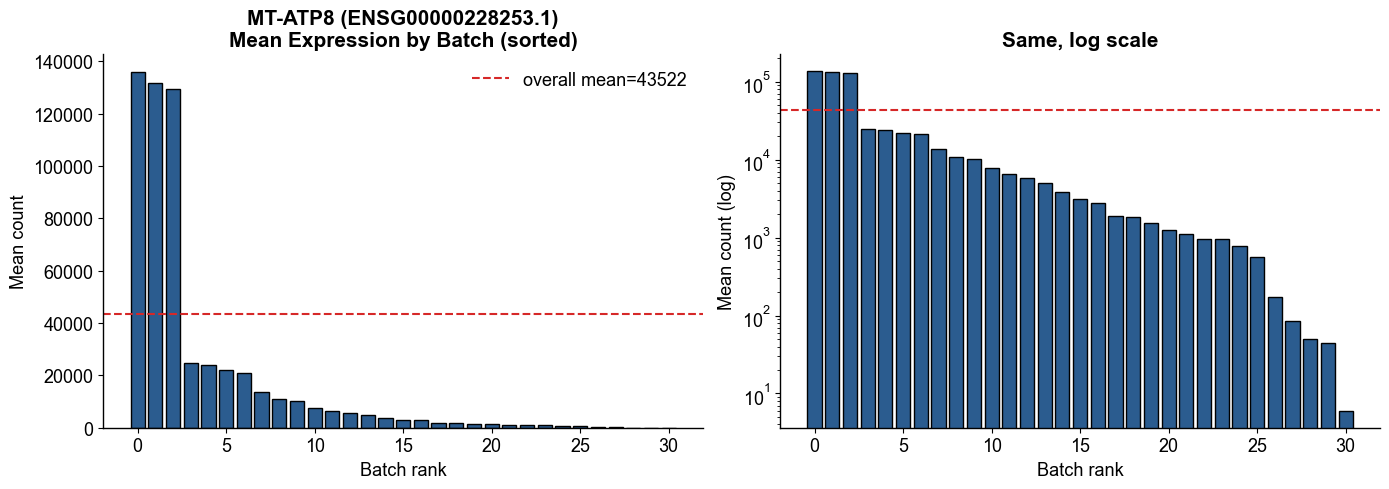

상위 3개 배치가 전체 배치평균 합의 69.7%를 차지 (총 31개 배치)
배치간 mean 범위: 6.0 ~ 135832.4 (비율 22639배)

=== Naive vs tau2-marginalized 비교 요약 ===
       mean_bias_naive_pct  mean_bias_corrected_pct  cov50_naive  \
count            13.000000                13.000000    13.000000   
mean            -49.651759                 6.126010     0.214452   
std              12.386219                20.418484     0.043905   
min             -78.672394               -40.688527     0.177489   
25%             -57.165051                -2.030484     0.184704   
50%             -47.752372                11.805470     0.197691   
75%             -42.140393                20.429790     0.217893   
max             -33.440828                26.847456     0.321789   

       cov50_marginalized  
count           13.000000  
mean             0.212232  
std              0.040122  
min              0.177489  
25%              0.184704  
50%              0.194805  
75%              0.217893  
max              0.304473  


In [24]:
# 3. 배치별 발현 시각화: mean_bias가 가장 큰 미토콘드리아 유전자에서
# 소수 배치가 평균을 끌어올리는지 육안 확인
worst_gene = df_mito.sort_values('mean_bias_naive_pct').iloc[0]['gene']
worst_symbol = df_mito.sort_values('mean_bias_naive_pct').iloc[0]['symbol']
y_worst = Y[:, gmap[worst_gene]]

batch_means = pd.Series(y_worst).groupby(batch).mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(len(batch_means)), batch_means.values, color='#2b5c8f', edgecolor='black')
axes[0].axhline(y_worst.mean(), color='#d62828', linestyle='--', linewidth=1.5, label=f'overall mean={y_worst.mean():.0f}')
axes[0].set_title(f'{worst_symbol} ({worst_gene})\nMean Expression by Batch (sorted)', fontweight='bold')
axes[0].set_xlabel('Batch rank')
axes[0].set_ylabel('Mean count')
axes[0].legend(frameon=False)

axes[1].bar(range(len(batch_means)), batch_means.values, color='#2b5c8f', edgecolor='black')
axes[1].axhline(y_worst.mean(), color='#d62828', linestyle='--', linewidth=1.5)
axes[1].set_yscale('log')
axes[1].set_title('Same, log scale', fontweight='bold')
axes[1].set_xlabel('Batch rank')
axes[1].set_ylabel('Mean count (log)')

plt.tight_layout()
plt.show()

top3_share = batch_means.head(3).sum() / batch_means.sum() * 100
print(f"상위 3개 배치가 전체 배치평균 합의 {top3_share:.1f}%를 차지 (총 {len(batch_means)}개 배치)")
print(f"배치간 mean 범위: {batch_means.min():.1f} ~ {batch_means.max():.1f} (비율 {batch_means.max()/max(batch_means.min(),1):.0f}배)")

print()
print("=== Naive vs tau2-marginalized 비교 요약 ===")
print(df_mito[['mean_bias_naive_pct', 'mean_bias_corrected_pct', 'cov50_naive', 'cov50_marginalized']].describe())


## 13. Systematic Search: Which Other Genes Share the Mitochondrial Failure Pattern?
Section 12에서 미토콘드리아 유전자의 cov_50 붕괴 원인이 "소수 배치가 배치평균을 지배하는 극단적 이질성"임을 확인했습니다. 같은 패턴(tau2 마진화로도 cov_50이 개선되지 않는 유전자)이 chrM 외에도 있는지 `nbi_True` 19,080개 전체에서 찾고, 배치 집중도 지표로 보편적 필터링이 가능한지 검토합니다.


In [25]:
# 1. cov_50 극단치(이상값 0.5에서 크게 벗어난) 유전자 전수 조회 (tau2-marginalized df_cov 사용)
nbi_cov = df_cov[df_cov['stage_failure'] == 'nbi_True'].copy()
nbi_cov['chrom'] = nbi_cov['gene'].map(chrom_map)
nbi_cov['symbol'] = nbi_cov['gene'].map(name_map)
nbi_cov['is_mito'] = nbi_cov['chrom'] == 'chrM'

extreme = nbi_cov[(nbi_cov['cov_50'] < 0.30)]
print(f"cov_50 < 0.30인 유전자 수: {len(extreme)}")
print(f"이 중 chrM: {extreme['is_mito'].sum()}개")

extreme

cov_50 < 0.30인 유전자 수: 27
이 중 chrM: 12개


,gene,stage_failure,nz,cov_25,cov_50,cov_90,cov_95,cov_99,nz_qdecile,chrom,symbol,is_mito
415,ENSG00000022567.11,nbi_True,678,0.083694,0.287157,0.955267,0.982684,0.998557,"(676.0, 687.0]",chr8,SLC45A4,False
2501,ENSG00000101421.5,nbi_True,685,0.043290,0.197691,0.998557,1.000000,1.000000,"(676.0, 687.0]",chr20,CHMP4B,False
3242,ENSG00000106244.14,nbi_True,688,0.044733,0.277056,0.898990,0.971140,1.000000,"(687.0, 693.0]",chr7,PDAP1,False
3553,ENSG00000108819.12,nbi_True,679,0.057720,0.232323,0.992785,0.998557,1.000000,"(676.0, 687.0]",chr17,PPP1R9B,False
9183,ENSG00000150681.10,nbi_True,693,0.090909,0.274170,0.946609,0.984127,1.000000,"(687.0, 693.0]",chr1,RGS18,False
9214,ENSG00000151023.17,nbi_True,687,0.111111,0.292929,0.923521,0.972583,0.998557,"(676.0, 687.0]",chr10,ENKUR,False
10164,ENSG00000159256.13,nbi_True,691,0.101010,0.246753,0.836941,0.958153,0.995671,"(687.0, 693.0]",chr21,MORC3,False
11003,ENSG00000163960.14,nbi_True,687,0.116883,0.282828,0.779221,0.862915,1.000000,"(676.0, 687.0]",chr3,UBXN7,False
12982,ENSG00000172216.7,nbi_True,684,0.102453,0.298701,0.897547,0.974026,0.998557,"(676.0, 687.0]",chr20,CEBPB,False
15236,ENSG00000185262.10,nbi_True,682,0.082251,0.292929,0.920635,0.982684,1.000000,"(676.0, 687.0]",chr17,UBALD2,False


In [26]:
# cov_25/50/75/90를 nbi_True 전체 및 cov_50<0.30 서브셋에서 비교
probs4 = np.array([0.25, 0.50, 0.75, 0.90])

nbi_cov_all = df_cov[df_cov['stage_failure'] == 'nbi_True'].copy()
under_genes = nbi_cov_all[nbi_cov_all['cov_50'] < 0.30]['gene'].tolist()
print(f"cov_50 < 0.30인 nbi_True 유전자 수: {len(under_genes)}")

rows = []
for g in under_genes:
    fo = genes_fit[g]
    y = Y[:, gmap[g]]
    mu = np.exp(X_design @ fo.mu_coef)
    if fo.disp_coef is not None and not np.all(np.isnan(fo.disp_coef)):
        alpha = np.exp(-X_design @ fo.disp_coef)
    else:
        alpha = np.full(len(y), fo.fixed_alpha or 1.0)
    tau2 = fo.tau2 if fo.tau2 is not None else 0.0

    q25, q50, q75, q90 = nb_marginal_quantiles(mu, alpha, tau2, probs4)
    rows.append({
        'gene': g, 'symbol': name_map.get(g, g), 'chrom': chrom_map.get(g, '?'), 'nz': int((y > 0).sum()),
        'cov_25': (y <= q25).mean(), 'cov_50': (y <= q50).mean(),
        'cov_75': (y <= q75).mean(), 'cov_90': (y <= q90).mean(),
    })

df_multi = pd.DataFrame(rows).sort_values('cov_50')
pd.set_option('display.max_rows', 40)
display(df_multi)

print()
print("=== cov_50<0.30 서브셋 요약 ===")
print(df_multi[['cov_25', 'cov_50', 'cov_75', 'cov_90']].describe())
print()
print("=== 참고: nbi_True 전체 분포 (정상 범위 감 잡기용) ===")
print(nbi_cov_all[['cov_25', 'cov_50', 'cov_90']].describe())


cov_50 < 0.30인 nbi_True 유전자 수: 27


,gene,symbol,chrom,nz,cov_25,cov_50,cov_75,cov_90
19,ENSG00000198888.2,MT-ND1,chrM,693,0.064935,0.177489,0.767677,0.975469
20,ENSG00000198899.2,MT-ATP6,chrM,693,0.063492,0.178932,0.702742,0.962482
12,ENSG00000198712.1,MT-CO2,chrM,693,0.063492,0.184704,0.774892,0.974026
18,ENSG00000198886.2,MT-ND4,chrM,693,0.077922,0.184704,0.733045,0.956710
14,ENSG00000198763.3,MT-ND2,chrM,693,0.062049,0.186147,0.705628,0.952381
13,ENSG00000198727.2,MT-CYB,chrM,693,0.080808,0.189033,0.730159,0.958153
17,ENSG00000198840.2,MT-ND3,chrM,693,0.076479,0.194805,0.669553,0.955267
1,ENSG00000101421.5,CHMP4B,chr20,685,0.043290,0.197691,0.799423,0.998557
16,ENSG00000198804.2,MT-CO1,chrM,693,0.070707,0.202020,0.761905,0.943723
21,ENSG00000198938.2,MT-CO3,chrM,693,0.067821,0.215007,0.738817,0.965368



=== cov_50<0.30 서브셋 요약 ===
          cov_25     cov_50     cov_75     cov_90
count  27.000000  27.000000  27.000000  27.000000
mean    0.082679   0.239485   0.690877   0.925926
std     0.026622   0.043441   0.106009   0.069728
min     0.043290   0.177489   0.492063   0.759019
25%     0.063492   0.196248   0.655123   0.904040
50%     0.080808   0.243867   0.702742   0.955267
75%     0.099567   0.278499   0.750361   0.969697
max     0.142857   0.298701   0.919192   0.998557

=== 참고: nbi_True 전체 분포 (정상 범위 감 잡기용) ===
             cov_25        cov_50        cov_90
count  19080.000000  19080.000000  19080.000000
mean       0.462707      0.612666      0.928106
std        0.284070      0.179707      0.027831
min        0.028860      0.177489      0.649351
25%        0.233766      0.481962      0.917749
50%        0.305916      0.525253      0.927850
75%        0.751804      0.754690      0.939394
max        0.997114      0.997114      1.000000


In [27]:
# 1. nbi_True 전체에 대해 실제 marginal_nb_rqr Z-score의 skew/kurtosis 계산 (캐시 우선)
import os
from scipy.stats import skew, kurtosis
from core.marginal_rqr import marginal_nb_rqr

zmoment_path = './engine_state_mixed/nbi_zscore_moments.csv'
if os.path.exists(zmoment_path):
    df_zmoment = pd.read_csv(zmoment_path)
else:
    nbi_all = summ[summ['stage_failure'] == 'nbi_True']['gene'].tolist()
    rows = []
    for g in nbi_all:
        fo = genes_fit[g]
        y = Y[:, gmap[g]]
        mu = np.exp(X_design @ fo.mu_coef)
        if fo.disp_coef is not None and not np.all(np.isnan(fo.disp_coef)):
            alpha = np.exp(-X_design @ fo.disp_coef)
        else:
            alpha = np.full(len(y), fo.fixed_alpha or 1.0)
        tau2 = fo.tau2 if fo.tau2 is not None else 0.0
        z = marginal_nb_rqr(y, mu, alpha, tau2, 42)
        rows.append({'gene': g, 'skew': skew(z), 'kurtosis_excess': kurtosis(z, fisher=True)})
    df_zmoment = pd.DataFrame(rows)
    df_zmoment.to_csv(zmoment_path, index=False)

df_zmoment['symbol'] = df_zmoment['gene'].map(name_map)
df_zmoment['chrom'] = df_zmoment['gene'].map(chrom_map)
print(f"n = {len(df_zmoment)}")
print(df_zmoment[['skew', 'kurtosis_excess']].describe(percentiles=[.5, .75, .9, .95, .99, .995, .999]))


n = 19080
               skew  kurtosis_excess
count  19080.000000     19080.000000
mean      -0.261444         0.635989
std        0.399896         1.449461
min       -4.400179        -1.108003
50%       -0.172456         0.136578
75%        0.030301         0.970577
90%        0.073044         1.906561
95%        0.103131         2.768432
99%        0.212745         7.110022
99.5%      0.288051         9.583338
99.9%      0.650755        13.903819
max        1.581315        23.206602


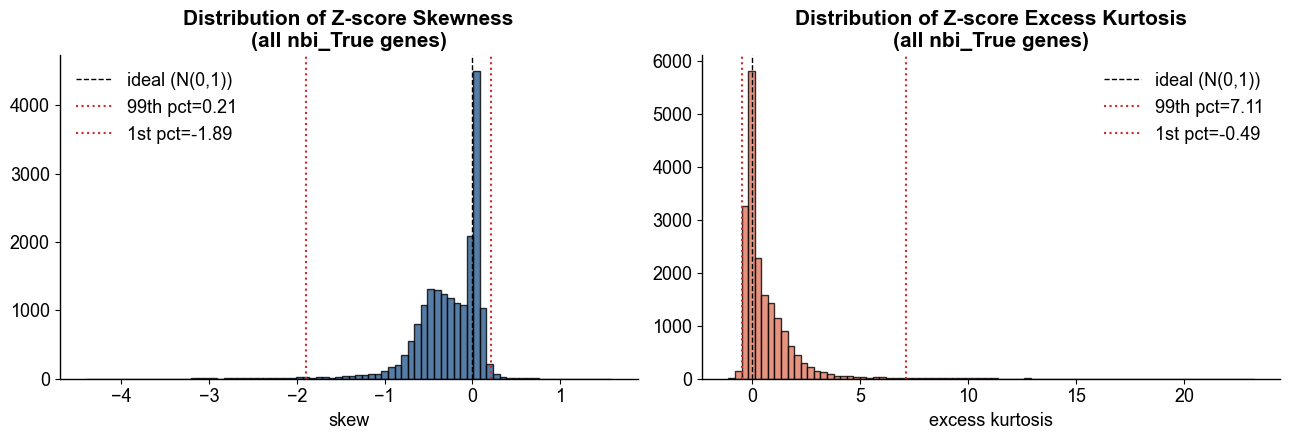

kurtosis_excess > 99th pct(7.11) 유전자 수: 191


In [30]:
# 2. 분포 시각화 + outlier 기준(예: kurtosis_excess 상위 1%, 99th percentile) 표시
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df_zmoment['skew'], bins=80, color='#2b5c8f', edgecolor='black', alpha=0.8)
axes[0].axvline(0, color='black', linewidth=1, linestyle='--', label='ideal (N(0,1))')
axes[0].set_title('Distribution of Z-score Skewness\n(all nbi_True genes)', fontweight='bold')
q99 = df_zmoment['skew'].quantile(0.99)
q1 = df_zmoment['skew'].quantile(0.01)
axes[0].axvline(q99, color='#d62828', linewidth=1.5, linestyle=':', label=f'99th pct={q99:.2f}')
axes[0].axvline(q1, color='#d62828', linewidth=1.5, linestyle=':', label=f'1st pct={q1:.2f}')
axes[0].set_xlabel('skew')
axes[0].legend(frameon=False)

axes[1].hist(df_zmoment['kurtosis_excess'], bins=80, color='#e07a5f', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=1, linestyle='--', label='ideal (N(0,1))')
q99 = df_zmoment['kurtosis_excess'].quantile(0.99)
q1 = df_zmoment['kurtosis_excess'].quantile(0.01)
axes[1].axvline(q99, color='#d62828', linewidth=1.5, linestyle=':', label=f'99th pct={q99:.2f}')
axes[1].axvline(q1, color='#d62828', linewidth=1.5, linestyle=':', label=f'1st pct={q1:.2f}')
axes[1].set_title('Distribution of Z-score Excess Kurtosis\n(all nbi_True genes)', fontweight='bold')
axes[1].set_xlabel('excess kurtosis')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

kurt_outliers = df_zmoment[df_zmoment['kurtosis_excess'] > q99]
print(f"kurtosis_excess > 99th pct({q99:.2f}) 유전자 수: {len(kurt_outliers)}")


In [31]:
# 3. Section 14의 cov_50<0.30 27개가 이 skew/kurtosis 분포에서 어느 위치인지 확인
under_genes = nbi_cov_all[nbi_cov_all['cov_50'] < 0.30]['gene'].tolist()

df_zmoment['kurt_pctrank'] = df_zmoment['kurtosis_excess'].rank(pct=True)
df_zmoment['skew_pctrank'] = df_zmoment['skew'].rank(pct=True)

under_z = df_zmoment[df_zmoment['gene'].isin(under_genes)].sort_values('kurtosis_excess', ascending=False)
print(f"cov_50<0.30 27개 중 kurtosis_excess 상위 1%(99th pct) 안에 드는 유전자: "
      f"{(under_z['kurtosis_excess'] > q99).sum()} / {len(under_z)}")
display(under_z[['symbol', 'chrom', 'skew', 'kurtosis_excess', 'skew_pctrank', 'kurt_pctrank']])


cov_50<0.30 27개 중 kurtosis_excess 상위 1%(99th pct) 안에 드는 유전자: 10 / 27


,symbol,chrom,skew,kurtosis_excess,skew_pctrank,kurt_pctrank
17170,PPP3R1,chr2,-4.400179,23.206602,0.000052,1.000000
2479,CHMP4B,chr20,-4.308945,22.641829,0.000105,0.999948
16542,PBX2,chr6,-3.345674,13.910187,0.000524,0.999004
3506,PPP1R9B,chr17,-3.125412,13.219271,0.000943,0.998585
3204,PDAP1,chr7,-2.683911,12.172740,0.002463,0.997956
17068,HNRNPUL2,chr11,-2.254674,9.017730,0.005818,0.993920
16376,MT-ND1,chrM,-2.435547,7.751193,0.003983,0.991771
411,SLC45A4,chr8,-2.034858,7.643749,0.008438,0.991457
14830,UBALD2,chr17,-2.098790,7.452347,0.007600,0.990985
16382,MT-ATP6,chrM,-2.330657,7.315411,0.005084,0.990566


In [42]:
print(len(df_zmoment[df_zmoment['skew'].abs() > 2.0])) # 164 
print(len(df_zmoment[df_zmoment['kurtosis_excess'].abs() > 7.0])) # 196
print(len(df_zmoment[(df_zmoment['skew'].abs() > 2.0) | (df_zmoment['kurtosis_excess'].abs() > 7.0)])) # 206
mask = (df_zmoment['skew'].abs() > 2.0) | (df_zmoment['kurtosis_excess'].abs() > 7.0)
df_zmoment[mask]

164
196
206


,gene,skew,kurtosis_excess,symbol,chrom,kurt_pctrank,skew_pctrank
28,ENSG00000002834.20,-2.081222,9.537247,LASP1,chr17,0.994864,0.007704
122,ENSG00000006125.19,-2.413732,10.968316,AP2B1,chr17,0.997222,0.004088
194,ENSG00000008083.15,-1.916907,10.828297,JARID2,chr6,0.996960,0.009748
282,ENSG00000011258.17,-2.284794,10.116616,MBTD1,chr17,0.995964,0.005556
411,ENSG00000022567.11,-2.034858,7.643749,SLC45A4,chr8,0.991457,0.008438
...,...,...,...,...,...,...,...
17170,ENSG00000221823.11,-4.400179,23.206602,PPP3R1,chr2,1.000000,0.000052
17995,ENSG00000257103.10,-2.359045,9.803281,LSM14A,chr19,0.995440,0.004874
18001,ENSG00000257315.4,-2.551294,8.619047,ZBED6,chr1,0.993396,0.003249
18595,ENSG00000277224.3,-2.038246,6.600622,H2BC7,chr6,0.988470,0.008333


## 16. Pilot: SHASH-Based Per-Gene Threshold Calibration
Section 15에서 확인한 27개(cov_50<0.30, location bias)와 206개(|skew|>2.0 또는 |kurtosis|>7.0, shape distortion) 문제 유전자를 배제하는 대신, SHASH(Sinh-Arcsinh, Jones & Pewsey 2009; de Boer et al. 2024 non-Gaussian normative modeling)로 유전자별 실제 Z 분포 모양(location/scale/skew/kurtosis)에 맞춘 보정 임계값을 산출해봅니다. **주의: 이 파일럿은 in-sample(같은 HC 데이터로 SHASH를 적합하고 같은 데이터로 검증)이라 SHASH 자체의 exceedance율은 순환논리적으로 5%에 가깝게 나올 수 있음 — 여기서 보고 싶은 건 naive N(0,1) 임계값이 실제로 얼마나 어긋나 있는지, 그리고 SHASH 보정폭이 문제군 vs 정상군에서 얼마나 차이나는지입니다.**

In [48]:
# 1. 27+206 문제 유전자 합집합 + 정상 대조군 50개의 raw Z-score 캐싱 (cache-first)
import os
import pickle

problem_genes = sorted(set(under_genes) | set(df_zmoment.loc[mask, 'gene']))
np.random.seed(42)
control_pool = df_zmoment[(df_zmoment['skew'].abs() < 0.3) & (df_zmoment['kurtosis_excess'].abs() < 0.5)]['gene']
control_genes = list(np.random.choice(control_pool, size=50, replace=False))
subset_genes = problem_genes + control_genes

zraw_path = './engine_state_mixed/shash_pilot_zraw.pkl'
if os.path.exists(zraw_path):
    with open(zraw_path, 'rb') as f:
        zraw = pickle.load(f)
else:
    zraw = {}
    for g in subset_genes:
        fo = genes_fit[g]
        y = Y[:, gmap[g]]
        mu = np.exp(X_design @ fo.mu_coef)
        if fo.disp_coef is not None and not np.all(np.isnan(fo.disp_coef)):
            alpha = np.exp(-X_design @ fo.disp_coef)
        else:
            alpha = np.full(len(y), fo.fixed_alpha or 1.0)
        tau2 = fo.tau2 if fo.tau2 is not None else 0.0
        zraw[g] = marginal_nb_rqr(y, mu, alpha, tau2, 42)
    with open(zraw_path, 'wb') as f:
        pickle.dump(zraw, f)

print(f"problem genes: {len(problem_genes)}, control genes: {len(control_genes)}, cached total: {len(zraw)}")


problem genes: 219, control genes: 50, cached total: 269


In [49]:
# 2. SHASH(xi, eta, eps, delta) MLE 적합 + 95% 보정 임계값 vs naive N(0,1) 1.96 비교
from scipy.optimize import minimize
from scipy.stats import norm

def shash_logpdf(x, xi, eta, eps, delta):
    z = (x - xi) / eta
    S = np.sinh(delta * np.arcsinh(z) - eps)
    C = np.sqrt(1 + S**2)
    return (np.log(delta) + np.log(C) - np.log(eta) - 0.5 * np.log(2 * np.pi)
            - 0.5 * np.log(1 + z**2) - 0.5 * S**2)

def shash_quantile(p, xi, eta, eps, delta):
    zq = norm.ppf(p)
    return xi + eta * np.sinh((np.arcsinh(zq) + eps) / delta)

def fit_shash(x):
    def negll(params):
        xi, log_eta, eps, log_delta = params
        eta, delta = np.exp(log_eta), np.exp(log_delta)
        ll = shash_logpdf(x, xi, eta, eps, delta)
        return 1e10 if not np.all(np.isfinite(ll)) else -ll.sum()
    x0 = [np.median(x), np.log(x.std()), 0.0, 0.0]
    res = minimize(negll, x0, method='Nelder-Mead', options={'maxiter': 3000, 'xatol': 1e-7, 'fatol': 1e-7})
    xi, log_eta, eps, log_delta = res.x
    return xi, np.exp(log_eta), eps, np.exp(log_delta), res.success

shash_path = './engine_state_mixed/shash_pilot_fit.csv'
if os.path.exists(shash_path):
    df_shash = pd.read_csv(shash_path)
else:
    rows = []
    for g in subset_genes:
        z = zraw[g].astype(np.float64)
        xi, eta, eps, delta, ok = fit_shash(z)
        z_lo, z_hi = shash_quantile(np.array([0.025, 0.975]), xi, eta, eps, delta)
        naive_exceed = np.mean((z < -1.96) | (z > 1.96))
        shash_exceed = np.mean((z < z_lo) | (z > z_hi))
        rows.append(dict(gene=g, group='problem' if g in problem_genes else 'control',
                          xi=xi, eta=eta, eps=eps, delta=delta, converged=ok,
                          z_lo=z_lo, z_hi=z_hi, naive_exceed=naive_exceed, shash_exceed=shash_exceed))
    df_shash = pd.DataFrame(rows)
    df_shash.to_csv(shash_path, index=False)

df_shash['symbol'] = df_shash['gene'].map(name_map)
df_shash['width'] = df_shash['z_hi'] - df_shash['z_lo']
print(df_shash.groupby('group')[['z_lo', 'z_hi', 'width', 'naive_exceed', 'shash_exceed']].mean())


             z_lo      z_hi     width  naive_exceed  shash_exceed
group                                                            
control -1.945748  1.893657  3.839405      0.047446      0.050649
problem -2.120641  1.212584  3.333225      0.031634      0.044687


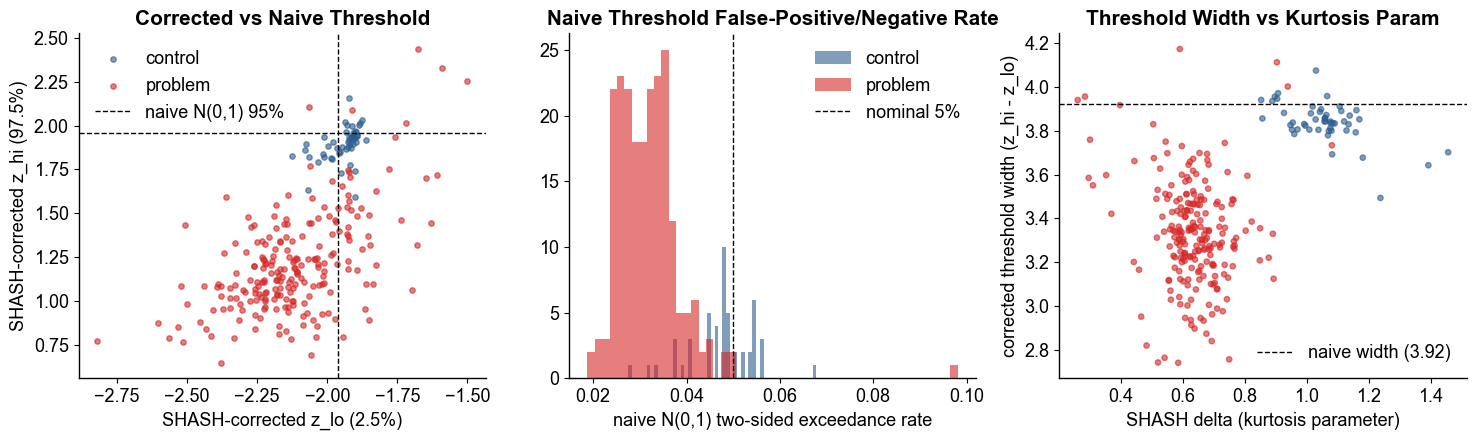

             mean       std       min       max
group                                          
control  0.047446  0.007186  0.027417  0.067821
problem  0.031634  0.007298  0.018759  0.098124


In [50]:
# 3. 시각화: 보정 임계값 vs naive, naive 임계값의 실제 위양성률, delta(kurtosis)와 보정폭 관계
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for grp, c in [('control', '#2b5c8f'), ('problem', '#d62828')]:
    sub = df_shash[df_shash['group'] == grp]
    axes[0].scatter(sub['z_lo'], sub['z_hi'], s=15, alpha=0.6, color=c, label=grp)
axes[0].axhline(1.96, color='black', linestyle='--', linewidth=1)
axes[0].axvline(-1.96, color='black', linestyle='--', linewidth=1, label='naive N(0,1) 95%')
axes[0].set_xlabel('SHASH-corrected z_lo (2.5%)')
axes[0].set_ylabel('SHASH-corrected z_hi (97.5%)')
axes[0].set_title('Corrected vs Naive Threshold', fontweight='bold')
axes[0].legend(frameon=False)

axes[1].hist(df_shash[df_shash.group == 'control']['naive_exceed'], bins=50, alpha=0.6, color='#2b5c8f', label='control')
axes[1].hist(df_shash[df_shash.group == 'problem']['naive_exceed'], bins=50, alpha=0.6, color='#d62828', label='problem')
axes[1].axvline(0.05, color='black', linestyle='--', linewidth=1, label='nominal 5%')
axes[1].set_xlabel('naive N(0,1) two-sided exceedance rate')
axes[1].set_title('Naive Threshold False-Positive/Negative Rate', fontweight='bold')
axes[1].legend(frameon=False)

colors = df_shash['group'].map({'problem': '#d62828', 'control': '#2b5c8f'})
axes[2].scatter(df_shash['delta'], df_shash['width'], s=15, alpha=0.6, c=colors)
axes[2].axhline(3.92, color='black', linestyle='--', linewidth=1, label='naive width (3.92)')
axes[2].set_xlabel('SHASH delta (kurtosis parameter)')
axes[2].set_ylabel('corrected threshold width (z_hi - z_lo)')
axes[2].set_title('Threshold Width vs Kurtosis Param', fontweight='bold')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

print(df_shash.groupby('group')['naive_exceed'].describe()[['mean', 'std', 'min', 'max']])


In [54]:
# 4. SHASH 역변환 기반 Z_corrected + BH-FDR (naive vs corrected p-value)
# 모든 zraw[g]는 HC(정상군) 데이터이므로 이론상 true positive가 없어야 함(complete null).
# naive p-value로 FDR을 걸었을 때 문제 유전자에서 위양성 비율이 얼마나 부풀려지는지,
# SHASH corrected p-value로 걸면 그게 정상군 수준으로 회복되는지 확인.
from scipy.stats import kurtosis, norm, skew
from statsmodels.stats.multitest import multipletests

def shash_transform_to_z(x, xi, eta, eps, delta):
    z_raw = (x - xi) / eta
    return np.sinh(delta * np.arcsinh(z_raw) - eps)

fdr_path = './engine_state_mixed/shash_pilot_fdr_check.csv'
if os.path.exists(fdr_path):
    df_fdr_check = pd.read_csv(fdr_path)
else:
    rows = []
    for _, r in df_shash.iterrows():
        g = r['gene']
        z = zraw[g].astype(np.float64)
        z_corr = shash_transform_to_z(z, r['xi'], r['eta'], r['eps'], r['delta'])
        p_naive = 2 * norm.sf(np.abs(z))
        p_corr = 2 * norm.sf(np.abs(z_corr))
        rej_naive, _, _, _ = multipletests(p_naive, alpha=0.05, method='fdr_bh')
        rej_corr, _, _, _ = multipletests(p_corr, alpha=0.05, method='fdr_bh')
        rows.append(dict(gene=g, group=r['group'],
                          corr_skew=skew(z_corr), corr_kurtosis=kurtosis(z_corr, fisher=True),
                          naive_fdr_reject_rate=rej_naive.mean(), corr_fdr_reject_rate=rej_corr.mean()))
    df_fdr_check = pd.DataFrame(rows)
    df_fdr_check.to_csv(fdr_path, index=False)

# 컬럼명 명확화: corr_* 는 "SHASH 보정 이후(corrected)" Z의 모멘트 -- 즉 이미 정규화된 값이라 낮은 게 정상.
# raw_* (df_zmoment, 원본 Z 기준)와 나란히 봐야 "이 유전자가 원래 얼마나 심했는지"가 드러남.
df_fdr_check = df_fdr_check.rename(columns={'corr_skew': 'z_corrected_skew', 'corr_kurtosis': 'z_corrected_kurtosis'})
df_fdr_check = df_fdr_check.merge(
    df_zmoment[['gene', 'skew', 'kurtosis_excess']].rename(columns={'skew': 'raw_skew', 'kurtosis_excess': 'raw_kurtosis'}),
    on='gene', how='left')
df_fdr_check['symbol'] = df_fdr_check['gene'].map(name_map)

print(df_fdr_check.groupby('group')[['raw_skew', 'raw_kurtosis', 'z_corrected_skew', 'z_corrected_kurtosis',
                                      'naive_fdr_reject_rate', 'corr_fdr_reject_rate']].mean())
print()
print("naive_fdr_reject_rate 상위 10개 (naive 방식으로 가장 많이 '위양성' 처리되는 유전자):")
display(df_fdr_check.sort_values('naive_fdr_reject_rate', ascending=False)
        [['gene', 'symbol', 'group', 'raw_skew', 'raw_kurtosis', 'z_corrected_skew', 'z_corrected_kurtosis',
          'naive_fdr_reject_rate', 'corr_fdr_reject_rate']].head(10))


         raw_skew  raw_kurtosis  z_corrected_skew  z_corrected_kurtosis  \
group                                                                     
control -0.001216     -0.092656          0.038103             -0.021470   
problem -2.300610      9.645061         -0.203062              0.679299   

         naive_fdr_reject_rate  corr_fdr_reject_rate  
group                                                 
control               0.000000              0.000029  
problem               0.016334              0.000507  

naive_fdr_reject_rate 상위 10개 (naive 방식으로 가장 많이 '위양성' 처리되는 유전자):


,gene,symbol,group,raw_skew,raw_kurtosis,z_corrected_skew,z_corrected_kurtosis,naive_fdr_reject_rate,corr_fdr_reject_rate
155,ENSG00000171735.21,CAMTA1,problem,0.316219,7.081842,0.299859,1.184297,0.034632,0.000000
107,ENSG00000142784.17,WDTC1,problem,-2.672784,10.092365,-0.515168,0.886009,0.033189,0.000000
7,ENSG00000055208.21,TAB2,problem,-2.830144,11.277464,-0.068103,1.274325,0.031746,0.001443
134,ENSG00000162889.12,MAPKAPK2,problem,-2.609393,10.532907,-0.444752,1.393260,0.030303,0.000000
153,ENSG00000171552.15,BCL2L1,problem,-2.487143,9.794587,-0.291895,0.802402,0.030303,0.000000
42,ENSG00000102908.24,NFAT5,problem,-2.998073,12.223283,0.076901,1.249205,0.028860,0.001443
80,ENSG00000124198.11,ARFGEF2,problem,-2.102923,6.385130,-0.191261,0.246930,0.028860,0.000000
136,ENSG00000163349.23,HIPK1,problem,-2.682816,10.725134,-0.151227,1.302275,0.027417,0.000000
125,ENSG00000157625.17,TAB3,problem,-2.201044,7.634474,-0.086530,0.699426,0.025974,0.000000
123,ENSG00000156860.16,FBRS,problem,-2.855489,11.043822,-0.245549,0.519976,0.025974,0.000000
